# Figure 4 — STABL heatmap and STABL vs LIMMA top20-combined6 comparison

This notebook generates publication-style Figure 4 outputs using the existing STABL and LIMMA feature files.

Outputs:

- **Figure 4A:** STABL-selected protein heatmap.
- **Figure 4B:** STABL vs LIMMA UMAP comparison using year × tissue panels.
- **Figure 4C:** Quantitative STABL vs LIMMA separation summary.
- **Figure 4 combined panel:** A 170 mm wide publication panel assembled from the generated figure files.

Important LIMMA rule:

- LIMMA features are **not truncated to k = 20**.
- Each LIMMA file is interpreted as **top 20 proteins per pairwise crop contrast across 6 contrasts**, so one `year × tissue` file can contain **at most 120 raw feature entries** before duplicate removal.
- The UMAP panels use the **full deduplicated year-specific LIMMA feature list** from `feature_set_crop_{year}_tissue_{tissue}_top20_combined6_no_nosema.csv`.
- Therefore, `k` in each LIMMA UMAP title is the actual number of usable features after deduplication and matching to the abundance matrix, not a forced `k = 20`.
- STABL uses the tissue-specific STABL-selected protein list.
- UMAP is fitted separately for each `method × year × tissue` panel, so coordinates are descriptive and should not be directly compared across panels.


**Update:** the combined Figure 4 panel is redrawn directly from the data as a 170 mm wide vector-style Matplotlib figure, rather than being assembled from saved PNG panels.

In [15]:
# ============================================================
# 1. Imports, paths, and global settings
# ============================================================

from pathlib import Path
import warnings
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances

try:
    import umap.umap_ as umap
except ImportError as e:
    raise ImportError("This notebook requires umap-learn. Install it with: pip install umap-learn") from e

try:
    from scipy.cluster.hierarchy import linkage, leaves_list
    from scipy.spatial.distance import pdist
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
# Recommended: run this notebook from the project/code folder.
CWD = Path.cwd()

if CWD.name.lower() == "code":
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = CWD

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results" / "figure4_stabl_vs_limma_top20combined6_max120_panel170mm"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

METADATA_FILE = DATA_DIR / "diagram.csv"

# Protein abundance files.
# The notebook first tries the STABL heatmap files and falls back to the LIMMA expression-wide files.
ABUNDANCE_2020_CANDIDATES = [
    DATA_DIR / "t2_2020_log2_impute.csv",
    DATA_DIR / "Limma_2020_expr_wide.csv",
    DATA_DIR / "limma_2020_expr_wide.csv",
    DATA_DIR / "2020_expr_wide.csv",
]

ABUNDANCE_2021_CANDIDATES = [
    DATA_DIR / "t2_2021_log2_impute.csv",
    DATA_DIR / "Limma_2021_expr_wide.csv",
    DATA_DIR / "limma_2021_expr_wide.csv",
    DATA_DIR / "2021_expr_wide.csv",
]

# STABL feature files.
STABL_FILES = {
    "A": DATA_DIR / "stabl_union_rank_selected_only_prot_A.csv",
    "G": DATA_DIR / "stabl_union_rank_selected_only_prot_G.csv",
    "H": DATA_DIR / "stabl_union_rank_selected_only_prot_H.csv",
}

# LIMMA year-specific feature files.
FEATURE_SEARCH_DIRS = [
    DATA_DIR / "crop_feature_sets_top20_no_nosema" / "combined_by_tissue",
    DATA_DIR / "combined_by_tissue_20",
    DATA_DIR,
]

TISSUES = ["A", "G", "H"]
YEARS = [2020, 2021]
METHODS = ["STABL", "LIMMA"]

# ------------------------------------------------------------
# Important LIMMA setting
# ------------------------------------------------------------
# Do NOT force k = 20.
# The top20_combined6 files are treated as:
#     top 20 proteins per pairwise crop contrast × 6 crop contrasts = max 120 raw entries
# before duplicate removal.
# Here we keep the full deduplicated year-specific file list.
LIMMA_TOP_N_PER_CONTRAST = 20
LIMMA_N_PAIRWISE_CONTRASTS = 6
LIMMA_MAX_FEATURES_PER_YEAR_TISSUE = LIMMA_TOP_N_PER_CONTRAST * LIMMA_N_PAIRWISE_CONTRASTS
USE_FULL_LIMMA_YEAR_SPECIFIC_FEATURES = True

# Location mapping from geo_cluster_100km.
GEO_CLUSTER_COL = "geo_cluster_100km"
LOCATION_COL = "geo_cluster_region"
GEO_CLUSTER_REGION = {
    0: "1. BC",
    4: "2. AB (N)",
    3: "3. AB (S)",
    2: "4. MB",
    1: "5. QC",
}
LOCATION_ORDER = list(GEO_CLUSTER_REGION.values()) + ["Unknown location"]

# Heatmap settings.
CLUSTER_SAMPLES = True
CLUSTER_PROTEINS = True
FILL_MISSING_ZSCORES_WITH_ZERO = True

# UMAP settings.
UMAP_RANDOM_STATE = 42
UMAP_N_NEIGHBORS = 8
UMAP_MIN_DIST = 0.20
SCALE_UMAP_WITHIN_EACH_PANEL = True

# Publication style.
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
    "font.size": 8,
    "axes.linewidth": 0.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "savefig.dpi": 600,
})

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)


PROJECT_ROOT: c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a
DATA_DIR: c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\data
RESULTS_DIR: c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm


In [16]:
# ============================================================
# 2. Loading helpers
# ============================================================

def pick_existing(candidates):
    for p in candidates:
        if p.exists():
            return p
    return candidates[0]


ABUNDANCE_2020_FILE = pick_existing(ABUNDANCE_2020_CANDIDATES)
ABUNDANCE_2021_FILE = pick_existing(ABUNDANCE_2021_CANDIDATES)


def standardize_sample_column(df):
    rename_candidates = {
        "sample": "sample_id",
        "Sample": "sample_id",
        "SampleID": "sample_id",
        "sampleID": "sample_id",
        "sample_name": "sample_id",
    }

    for old, new in rename_candidates.items():
        if old in df.columns and new not in df.columns:
            df = df.rename(columns={old: new})

    return df


def check_required_files():
    required = [
        METADATA_FILE,
        ABUNDANCE_2020_FILE,
        ABUNDANCE_2021_FILE,
    ] + list(STABL_FILES.values())

    missing = [str(p) for p in required if not p.exists()]

    if missing:
        raise FileNotFoundError(
            "Missing required files:\n"
            + "\n".join(missing)
            + "\n\nRun this notebook from the code/ folder and make sure data/ is at the same project level as code/."
        )


def strip_prot_prefix(x):
    x = str(x)
    if x.startswith("prot__"):
        return x.replace("prot__", "", 1)
    return x


def dedupe_preserve_order(items):
    seen = set()
    out = []

    for x in items:
        if pd.isna(x):
            continue

        x = str(x).strip()

        if not x:
            continue

        # Safety filter: exclude non-bee Nosema annotations if they appear.
        if "Nosema" in x:
            continue

        if x not in seen:
            seen.add(x)
            out.append(x)

    return out


def load_metadata():
    meta = pd.read_csv(METADATA_FILE).copy()
    meta = standardize_sample_column(meta)

    required_cols = ["sample_id", "crop", "tissue", "year"]
    missing_cols = [c for c in required_cols if c not in meta.columns]

    if missing_cols:
        raise ValueError(f"Missing metadata columns: {missing_cols}")

    if "exposure" not in meta.columns:
        meta["exposure"] = "Unknown"

    if GEO_CLUSTER_COL in meta.columns:
        meta[GEO_CLUSTER_COL] = pd.to_numeric(meta[GEO_CLUSTER_COL], errors="coerce")
        meta[LOCATION_COL] = meta[GEO_CLUSTER_COL].map(GEO_CLUSTER_REGION)

        missing_region = meta[LOCATION_COL].isna()

        if missing_region.any():
            warnings.warn(
                f"{missing_region.sum()} samples have unmapped {GEO_CLUSTER_COL} values. "
                "They will be labeled as 'Unknown location'."
            )
            meta.loc[missing_region, LOCATION_COL] = "Unknown location"

    elif LOCATION_COL not in meta.columns:
        location_fallbacks = ["location", "Location", "province", "Province", "region", "Region"]
        chosen = next((c for c in location_fallbacks if c in meta.columns), None)

        if chosen is not None:
            meta[LOCATION_COL] = meta[chosen].astype(str)
        else:
            meta[LOCATION_COL] = "Unknown location"

    for col in ["sample_id", "crop", "tissue", "year", "exposure", LOCATION_COL]:
        meta[col] = meta[col].astype(str)

    return meta


def load_abundance():
    df20 = pd.read_csv(ABUNDANCE_2020_FILE).copy()
    df21 = pd.read_csv(ABUNDANCE_2021_FILE).copy()

    df20 = standardize_sample_column(df20)
    df21 = standardize_sample_column(df21)

    if "sample_id" not in df20.columns or "sample_id" not in df21.columns:
        raise ValueError("Abundance files must contain a 'sample' or 'sample_id' column.")

    df20["source_year"] = 2020
    df21["source_year"] = 2021

    abundance = pd.concat([df20, df21], axis=0, ignore_index=True, sort=False)
    abundance["sample_id"] = abundance["sample_id"].astype(str)
    abundance = abundance.drop_duplicates(subset="sample_id", keep="first")

    return abundance


def load_stabl_features():
    selected = {}
    summary_rows = []

    for tissue, path in STABL_FILES.items():
        df = pd.read_csv(path).copy()

        if "feature" not in df.columns:
            raise ValueError(f"{path.name} must contain a 'feature' column.")

        df["protein_id"] = df["feature"].map(strip_prot_prefix)

        if "rank" in df.columns:
            df = df.sort_values("rank")
        elif "union_stabl_score_max" in df.columns:
            df = df.sort_values("union_stabl_score_max", ascending=False)

        features = dedupe_preserve_order(df["protein_id"].astype(str).tolist())

        selected[tissue] = {
            "df": df,
            "features": features,
            "file": path,
        }

        summary_rows.append({
            "method": "STABL",
            "year": "all",
            "tissue": tissue,
            "feature_file": str(path),
            "n_features_in_file": len(features),
            "features": ";".join(features),
        })

    return selected, pd.DataFrame(summary_rows)


def find_limma_feature_file(year, tissue):
    patterns = [
        f"feature_set_crop_{year}_tissue_{tissue}_top20_combined6_no_nosema.csv",
        f"feature_set_crop_{year}_tissue_{tissue}_top20_combined6_no_nosema*.csv",
        f"*crop_{year}*tissue_{tissue}*top20*no_nosema*.csv",
    ]

    for search_dir in FEATURE_SEARCH_DIRS:
        if not search_dir.exists():
            continue

        for pattern in patterns:
            matches = sorted(search_dir.glob(pattern))

            if matches:
                return matches[0]

    return None


def infer_protein_id_column(df, fpath):
    """Return the most likely protein identifier column for STABL/LIMMA-style files."""
    candidates = [
        "protein_id", "Protein_ID", "protein", "Protein", "feature", "Feature",
        "gene", "Gene", "id", "ID",
    ]

    for col in candidates:
        if col in df.columns:
            return col

    # Last-resort fallback: use the first non-numeric-looking column.
    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            warnings.warn(
                f"Could not find a standard protein ID column in {fpath.name}; using '{col}' as fallback."
            )
            return col

    raise ValueError(
        f"Could not identify a protein ID column in {fpath}. "
        f"Available columns: {list(df.columns)}"
    )


def infer_contrast_column(df):
    """Try to detect a contrast/comparison column if it exists."""
    exact = ["contrast", "comparison", "pair", "crop_pair", "crop_contrast"]

    for col in df.columns:
        if col.lower() in exact:
            return col

    for col in df.columns:
        low = col.lower()
        if "contrast" in low or "comparison" in low or "pair" in low:
            return col

    return None


def load_limma_year_specific_features():
    """
    Load LIMMA year-specific top20_combined6 files.

    Interpretation used here:
    - Each file represents top 20 features from each of 6 pairwise crop contrasts.
    - Therefore, one year × tissue file has an expected upper bound of 120 raw entries.
    - We do NOT truncate to k=20.
    - We deduplicate while preserving order, so the final feature count can be less than 120.
    """
    features_by_year_tissue = {}
    combined_by_tissue = {}
    summary_rows = []

    for tissue in TISSUES:
        tissue_features_all_years = []

        for year in YEARS:
            fpath = find_limma_feature_file(year, tissue)

            if fpath is None:
                raise FileNotFoundError(
                    f"Could not find LIMMA no-Nosema feature file for year={year}, tissue={tissue}.\n"
                    f"Expected something like: feature_set_crop_{year}_tissue_{tissue}_top20_combined6_no_nosema.csv\n"
                    f"Searched in: {[str(p) for p in FEATURE_SEARCH_DIRS]}"
                )

            df = pd.read_csv(fpath).copy()
            protein_col = infer_protein_id_column(df, fpath)
            contrast_col = infer_contrast_column(df)

            protein_entries = [strip_prot_prefix(x) for x in df[protein_col].tolist()]
            protein_entries = [str(x).strip() for x in protein_entries if pd.notna(x) and str(x).strip()]
            protein_entries = [x for x in protein_entries if "Nosema" not in x]

            deduped_features = dedupe_preserve_order(protein_entries)

            n_raw_entries = len(protein_entries)
            n_unique = len(deduped_features)
            n_duplicates_removed = n_raw_entries - n_unique

            if n_raw_entries > LIMMA_MAX_FEATURES_PER_YEAR_TISSUE:
                warnings.warn(
                    f"LIMMA {year} Tissue {tissue}: found {n_raw_entries} raw entries, which is greater than "
                    f"the expected top20 × 6 upper bound ({LIMMA_MAX_FEATURES_PER_YEAR_TISSUE}). "
                    "Check whether the input file contains extra rows or a different feature-set definition."
                )

            if n_unique > LIMMA_MAX_FEATURES_PER_YEAR_TISSUE:
                warnings.warn(
                    f"LIMMA {year} Tissue {tissue}: found {n_unique} unique features, which is greater than "
                    f"the expected top20 × 6 upper bound ({LIMMA_MAX_FEATURES_PER_YEAR_TISSUE})."
                )

            if contrast_col is not None:
                n_contrasts_detected = df[contrast_col].astype(str).nunique(dropna=True)
                contrast_values = ";".join(sorted(df[contrast_col].dropna().astype(str).unique().tolist()))
            else:
                n_contrasts_detected = np.nan
                contrast_values = "not_available_in_file"

            features_by_year_tissue[(year, tissue)] = deduped_features
            tissue_features_all_years.extend(deduped_features)

            summary_rows.append({
                "method": "LIMMA",
                "year": year,
                "tissue": tissue,
                "feature_file": str(fpath),
                "selection_mode": "top20_per_pairwise_crop_contrast_combined6_full_deduplicated_max120",
                "protein_id_column_used": protein_col,
                "contrast_column_detected": contrast_col if contrast_col is not None else "not_available",
                "n_contrasts_detected": n_contrasts_detected,
                "contrast_values": contrast_values,
                "top_n_per_contrast": LIMMA_TOP_N_PER_CONTRAST,
                "n_pairwise_contrasts_expected": LIMMA_N_PAIRWISE_CONTRASTS,
                "expected_max_raw_entries": LIMMA_MAX_FEATURES_PER_YEAR_TISSUE,
                "n_raw_feature_entries_after_nosema_filter": n_raw_entries,
                "n_unique_features_after_dedup": n_unique,
                "n_duplicates_removed": n_duplicates_removed,
                "features": ";".join(deduped_features),
            })

        combined = dedupe_preserve_order(tissue_features_all_years)
        combined_by_tissue[tissue] = combined

        summary_rows.append({
            "method": "LIMMA",
            "year": "2020+2021",
            "tissue": tissue,
            "feature_file": "combined 2020 and 2021 year-specific LIMMA files",
            "selection_mode": "descriptive_combined_union_across_years_not_used_for_year_specific_umap",
            "protein_id_column_used": "year-specific files",
            "contrast_column_detected": "year-specific files",
            "n_contrasts_detected": np.nan,
            "contrast_values": "year-specific files",
            "top_n_per_contrast": LIMMA_TOP_N_PER_CONTRAST,
            "n_pairwise_contrasts_expected": LIMMA_N_PAIRWISE_CONTRASTS,
            "expected_max_raw_entries": LIMMA_MAX_FEATURES_PER_YEAR_TISSUE * len(YEARS),
            "n_raw_feature_entries_after_nosema_filter": np.nan,
            "n_unique_features_after_dedup": len(combined),
            "n_duplicates_removed": np.nan,
            "features": ";".join(combined),
        })

    return features_by_year_tissue, combined_by_tissue, pd.DataFrame(summary_rows)


check_required_files()

metadata = load_metadata()
abundance = load_abundance()
stabl_features, stabl_feature_summary = load_stabl_features()
limma_features_by_year_tissue, limma_features_combined_by_tissue, limma_feature_summary = load_limma_year_specific_features()

feature_source_summary = pd.concat(
    [stabl_feature_summary, limma_feature_summary],
    ignore_index=True,
    sort=False,
)

feature_source_summary_path = RESULTS_DIR / "Figure4_feature_source_summary_STABL_LIMMA_top20combined6_max120.csv"
feature_source_summary.to_csv(feature_source_summary_path, index=False)

print("Using metadata:", METADATA_FILE)
print("Using abundance 2020:", ABUNDANCE_2020_FILE)
print("Using abundance 2021:", ABUNDANCE_2021_FILE)
print("Metadata shape:", metadata.shape)
print("Abundance shape:", abundance.shape)
print("\nSaved feature source summary:")
print(feature_source_summary_path)

print("\nLIMMA top20-combined6 summary. Each year × tissue should be <= 120 before duplicate removal.")
limma_display_cols = [
    "method", "year", "tissue", "selection_mode",
    "n_raw_feature_entries_after_nosema_filter", "n_unique_features_after_dedup",
    "n_duplicates_removed", "expected_max_raw_entries", "feature_file",
]
display(limma_feature_summary[limma_display_cols].fillna(""))

print("\nAll feature source summary:")
summary_display_cols = [
    "method", "year", "tissue", "selection_mode", "n_features_in_file",
    "n_raw_feature_entries_after_nosema_filter", "n_unique_features_after_dedup", "feature_file",
]
summary_display_cols = [c for c in summary_display_cols if c in feature_source_summary.columns]
display(feature_source_summary[summary_display_cols].fillna(""))


Using metadata: c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\data\diagram.csv
Using abundance 2020: c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\data\t2_2020_log2_impute.csv
Using abundance 2021: c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\data\t2_2021_log2_impute.csv
Metadata shape: (240, 47)
Abundance shape: (240, 5974)

Saved feature source summary:
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4_feature_source_summary_STABL_LIMMA_top20combined6_max120.csv

LIMMA top20-combined6 summary. Each year × tissue should be <= 120 before duplicate removal.


,method,year,tissue,selection_mode,n_raw_feature_entries_after_nosema_filter,n_unique_features_after_dedup,n_duplicates_removed,expected_max_raw_entries,feature_file
0,LIMMA,2020,A,top20_per_pairwise_crop_contrast_combined6_ful...,83.0,83,0.0,120,c:\Users\junse\Documents\research\Bee_Protein_...
1,LIMMA,2021,A,top20_per_pairwise_crop_contrast_combined6_ful...,80.0,80,0.0,120,c:\Users\junse\Documents\research\Bee_Protein_...
2,LIMMA,2020+2021,A,descriptive_combined_union_across_years_not_us...,,155,,240,combined 2020 and 2021 year-specific LIMMA files
3,LIMMA,2020,G,top20_per_pairwise_crop_contrast_combined6_ful...,93.0,93,0.0,120,c:\Users\junse\Documents\research\Bee_Protein_...
4,LIMMA,2021,G,top20_per_pairwise_crop_contrast_combined6_ful...,83.0,83,0.0,120,c:\Users\junse\Documents\research\Bee_Protein_...
5,LIMMA,2020+2021,G,descriptive_combined_union_across_years_not_us...,,166,,240,combined 2020 and 2021 year-specific LIMMA files
6,LIMMA,2020,H,top20_per_pairwise_crop_contrast_combined6_ful...,76.0,76,0.0,120,c:\Users\junse\Documents\research\Bee_Protein_...
7,LIMMA,2021,H,top20_per_pairwise_crop_contrast_combined6_ful...,84.0,84,0.0,120,c:\Users\junse\Documents\research\Bee_Protein_...
8,LIMMA,2020+2021,H,descriptive_combined_union_across_years_not_us...,,153,,240,combined 2020 and 2021 year-specific LIMMA files



All feature source summary:


,method,year,tissue,selection_mode,n_features_in_file,n_raw_feature_entries_after_nosema_filter,n_unique_features_after_dedup,feature_file
0,STABL,all,A,,31.0,,,c:\Users\junse\Documents\research\Bee_Protein_...
1,STABL,all,G,,18.0,,,c:\Users\junse\Documents\research\Bee_Protein_...
2,STABL,all,H,,9.0,,,c:\Users\junse\Documents\research\Bee_Protein_...
3,LIMMA,2020,A,top20_per_pairwise_crop_contrast_combined6_ful...,,83.0,83.0,c:\Users\junse\Documents\research\Bee_Protein_...
4,LIMMA,2021,A,top20_per_pairwise_crop_contrast_combined6_ful...,,80.0,80.0,c:\Users\junse\Documents\research\Bee_Protein_...
5,LIMMA,2020+2021,A,descriptive_combined_union_across_years_not_us...,,,155.0,combined 2020 and 2021 year-specific LIMMA files
6,LIMMA,2020,G,top20_per_pairwise_crop_contrast_combined6_ful...,,93.0,93.0,c:\Users\junse\Documents\research\Bee_Protein_...
7,LIMMA,2021,G,top20_per_pairwise_crop_contrast_combined6_ful...,,83.0,83.0,c:\Users\junse\Documents\research\Bee_Protein_...
8,LIMMA,2020+2021,G,descriptive_combined_union_across_years_not_us...,,,166.0,combined 2020 and 2021 year-specific LIMMA files
9,LIMMA,2020,H,top20_per_pairwise_crop_contrast_combined6_ful...,,76.0,76.0,c:\Users\junse\Documents\research\Bee_Protein_...


In [17]:
# ============================================================
# 3. Prepare STABL heatmap matrices and method × year × tissue UMAP matrices
# ============================================================

def row_zscore_using_2020(matrix, sample_meta):
    """
    Heatmap scaling.
    matrix: rows = proteins, columns = samples.
    sample_meta: DataFrame indexed by sample_id with source_year/year information.
    """
    if "source_year" in sample_meta.columns:
        train_samples = sample_meta.index[sample_meta["source_year"].astype(str) == "2020"].tolist()
    else:
        train_samples = sample_meta.index[sample_meta["year"].astype(str) == "2020"].tolist()

    train_samples = [s for s in train_samples if s in matrix.columns]

    if len(train_samples) < 2:
        raise ValueError("Need at least 2 samples from 2020 for row z-score scaling.")

    train_values = matrix[train_samples]
    mu = train_values.mean(axis=1)
    sigma = train_values.std(axis=1).replace(0, np.nan)

    z = matrix.sub(mu, axis=0).div(sigma, axis=0)
    z = z.replace([np.inf, -np.inf], np.nan)

    if FILL_MISSING_ZSCORES_WITH_ZERO:
        z = z.fillna(0.0)

    return z.clip(-2.5, 2.5)


def zscore_within_panel(X):
    """
    UMAP scaling.
    X: rows = samples, columns = features.
    """
    mu = X.mean(axis=0)
    sd = X.std(axis=0, ddof=0).replace(0, 1.0)

    Xz = ((X - mu) / sd).replace([np.inf, -np.inf], np.nan)

    if FILL_MISSING_ZSCORES_WITH_ZERO:
        Xz = Xz.fillna(0.0)

    return Xz


def zscore_with_2020_reference_for_samples(X, merged):
    train_mask = merged["source_year"].astype(int) == 2020

    if train_mask.sum() < 2:
        # For year-specific panels, 2021-only panels do not contain 2020 reference samples.
        # Fall back to within-panel scaling.
        return zscore_within_panel(X), "within_year_tissue_panel_fallback"

    mu = X.loc[train_mask].mean(axis=0)
    sd = X.loc[train_mask].std(axis=0, ddof=0).replace(0, 1.0)

    Xz = ((X - mu) / sd).replace([np.inf, -np.inf], np.nan)

    if FILL_MISSING_ZSCORES_WITH_ZERO:
        Xz = Xz.fillna(0.0)

    return Xz, "2020_reference"


def cluster_order(df, axis=0):
    if not SCIPY_AVAILABLE:
        return list(range(df.shape[axis]))

    arr = df.values if axis == 0 else df.values.T

    if arr.shape[0] <= 2:
        return list(range(arr.shape[0]))

    try:
        dist = pdist(arr, metric="correlation")
        if np.any(~np.isfinite(dist)):
            dist = pdist(arr, metric="euclidean")

        Z = linkage(dist, method="average")
        return leaves_list(Z).tolist()

    except Exception:
        return list(range(arr.shape[0]))


def prepare_stabl_heatmap_tissue(tissue):
    meta_t = metadata.loc[metadata["tissue"].astype(str) == tissue].copy()

    merged = meta_t[["sample_id", "crop", "tissue", "year", LOCATION_COL, "exposure"]].merge(
        abundance,
        on="sample_id",
        how="inner",
    )

    if merged.empty:
        raise ValueError(f"No matching abundance samples found for tissue {tissue}.")

    selected_df = stabl_features[tissue]["df"].copy()
    selected_features = stabl_features[tissue]["features"]

    available_features = [f for f in selected_features if f in abundance.columns]
    missing_features = [f for f in selected_features if f not in abundance.columns]

    if len(available_features) == 0:
        raise ValueError(f"No selected STABL features for tissue {tissue} matched abundance columns.")

    if missing_features:
        warnings.warn(f"Tissue {tissue}: {len(missing_features)} STABL features were missing from abundance matrix.")

    X = merged.set_index("sample_id")[available_features].apply(pd.to_numeric, errors="coerce").T

    sample_meta = merged.set_index("sample_id")[[
        "crop", "tissue", "year", "source_year", LOCATION_COL, "exposure"
    ]].copy()

    sample_meta["source_year"] = sample_meta["source_year"].astype(int).astype(str)

    Xz = row_zscore_using_2020(X, sample_meta)

    if CLUSTER_PROTEINS:
        row_order = cluster_order(Xz, axis=0)
        Xz = Xz.iloc[row_order, :]

    if CLUSTER_SAMPLES:
        col_order = cluster_order(Xz, axis=1)
        Xz = Xz.iloc[:, col_order]
        sample_meta = sample_meta.loc[Xz.columns]
    else:
        sort_cols = ["source_year", "crop", LOCATION_COL, "exposure"]
        ordered_samples = sample_meta.sort_values(sort_cols).index.tolist()
        Xz = Xz[ordered_samples]
        sample_meta = sample_meta.loc[ordered_samples]

    return {
        "Xz": Xz,
        "sample_meta": sample_meta,
        "selected_df": selected_df,
        "available_features": available_features,
        "missing_features": missing_features,
    }


def get_requested_features(method, year, tissue):
    if method == "STABL":
        return list(stabl_features[tissue]["features"])
    elif method == "LIMMA":
        # This is the key line: LIMMA uses the year-specific raw deduplicated list.
        return list(limma_features_by_year_tissue[(year, tissue)])
    else:
        raise ValueError(f"Unknown method: {method}")


def prepare_method_year_tissue_umap_data(method, year, tissue):
    requested_features = get_requested_features(method, year, tissue)

    available_features = [f for f in requested_features if f in abundance.columns]
    missing_features = [f for f in requested_features if f not in abundance.columns]

    if len(available_features) == 0:
        raise ValueError(f"No {method} features for year={year}, tissue={tissue} matched abundance columns.")

    if missing_features:
        warnings.warn(
            f"{method} {year} Tissue {tissue}: {len(missing_features)} features were missing from abundance matrix."
        )

    sample_meta = metadata.loc[metadata["tissue"].astype(str) == tissue].copy()
    sample_meta = sample_meta.drop_duplicates(subset="sample_id", keep="first")

    merged = sample_meta.merge(
        abundance[["sample_id", "source_year"] + available_features],
        on="sample_id",
        how="inner",
    ).drop_duplicates(subset="sample_id", keep="first")

    merged = merged.loc[merged["source_year"].astype(int) == int(year)].copy()

    if merged.empty:
        raise ValueError(f"{method} {year} Tissue {tissue}: no samples after metadata-abundance merge.")

    merged["source_year"] = merged["source_year"].astype(int)
    merged["crop"] = merged["crop"].astype(str)
    merged["tissue"] = merged["tissue"].astype(str)
    merged[LOCATION_COL] = merged[LOCATION_COL].astype(str)
    merged["exposure"] = merged["exposure"].astype(str)

    X = merged[available_features].apply(pd.to_numeric, errors="coerce").copy()

    if SCALE_UMAP_WITHIN_EACH_PANEL:
        Xz = zscore_within_panel(X)
        scaling_mode = "within_method_year_tissue_panel"
    else:
        Xz, scaling_mode = zscore_with_2020_reference_for_samples(X, merged)

    feature_set_type = (
        "stabl_selected_proteins"
        if method == "STABL"
        else "year_specific_LIMMA_top20_per_contrast_combined6_no_Nosema_full_deduplicated_max120"
    )

    return {
        "method": method,
        "year": year,
        "tissue": tissue,
        "merged": merged,
        "X": X,
        "Xz": Xz,
        "features": available_features,
        "requested_features": requested_features,
        "missing_features": missing_features,
        "scaling_mode": scaling_mode,
        "feature_set_type": feature_set_type,
    }


# STABL heatmap data for Figure 4A.
stabl_heatmap_data = {}
stabl_heatmap_summary = []

for tissue in TISSUES:
    d = prepare_stabl_heatmap_tissue(tissue)
    stabl_heatmap_data[tissue] = d

    stabl_heatmap_summary.append({
        "tissue": tissue,
        "n_samples": d["Xz"].shape[1],
        "n_features_found": d["Xz"].shape[0],
        "n_features_missing": len(d["missing_features"]),
    })

stabl_heatmap_summary = pd.DataFrame(stabl_heatmap_summary)
stabl_heatmap_summary.to_csv(RESULTS_DIR / "Figure4A_STABL_heatmap_summary.csv", index=False)

print("STABL heatmap summary:")
display(stabl_heatmap_summary)


# Method × year × tissue UMAP data for Figure 4B/C.
method_panel_data = {}
method_panel_summary = []

for method in METHODS:
    for year in YEARS:
        for tissue in TISSUES:
            d = prepare_method_year_tissue_umap_data(method, year, tissue)
            method_panel_data[(method, year, tissue)] = d

            method_panel_summary.append({
                "method": method,
                "year": year,
                "tissue": tissue,
                "n_samples": len(d["merged"]),
                "n_requested_features_from_file": len(d["requested_features"]),
                "n_usable_features_in_abundance": len(d["features"]),
                "n_missing_features": len(d["missing_features"]),
                "scaling_mode": d["scaling_mode"],
                "feature_set_type": d["feature_set_type"],
            })

method_panel_summary = pd.DataFrame(method_panel_summary)
method_panel_summary.to_csv(RESULTS_DIR / "Figure4_method_year_tissue_umap_input_summary.csv", index=False)

print("Method/year/tissue UMAP input summary:")
display(method_panel_summary)


STABL heatmap summary:


,tissue,n_samples,n_features_found,n_features_missing
0,A,80,31,0
1,G,80,18,0
2,H,80,9,0


Method/year/tissue UMAP input summary:


,method,year,tissue,n_samples,n_requested_features_from_file,n_usable_features_in_abundance,n_missing_features,scaling_mode,feature_set_type
0,STABL,2020,A,40,31,31,0,within_method_year_tissue_panel,stabl_selected_proteins
1,STABL,2020,G,40,18,18,0,within_method_year_tissue_panel,stabl_selected_proteins
2,STABL,2020,H,40,9,9,0,within_method_year_tissue_panel,stabl_selected_proteins
3,STABL,2021,A,40,31,31,0,within_method_year_tissue_panel,stabl_selected_proteins
4,STABL,2021,G,40,18,18,0,within_method_year_tissue_panel,stabl_selected_proteins
5,STABL,2021,H,40,9,9,0,within_method_year_tissue_panel,stabl_selected_proteins
6,LIMMA,2020,A,40,83,83,0,within_method_year_tissue_panel,year_specific_LIMMA_top20_per_contrast_combine...
7,LIMMA,2020,G,40,93,93,0,within_method_year_tissue_panel,year_specific_LIMMA_top20_per_contrast_combine...
8,LIMMA,2020,H,40,76,76,0,within_method_year_tissue_panel,year_specific_LIMMA_top20_per_contrast_combine...
9,LIMMA,2021,A,40,80,80,0,within_method_year_tissue_panel,year_specific_LIMMA_top20_per_contrast_combine...


In [18]:
# ============================================================
# 4. Color palettes and shared plotting helpers
# ============================================================

def make_palette(values, cmap_name="tab20", order=None):
    values = [str(v) for v in pd.Series(values).dropna().unique().tolist()]

    if order is not None:
        order = [str(v) for v in order]
        values = [v for v in order if v in values] + sorted([v for v in values if v not in order])
    else:
        values = sorted(values)

    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(i % cmap.N) for i in range(len(values))]

    return dict(zip(values, colors))


crop_order = ["CAC", "CAS", "CRA", "HBB"]
crop_palette = make_palette(metadata["crop"], "tab10", order=crop_order)

year_palette = make_palette(["2020", "2021"], "Set2", order=["2020", "2021"])

location_palette = make_palette(
    metadata[LOCATION_COL].astype(str),
    "tab20",
    order=LOCATION_ORDER,
)

exposure_palette = make_palette(metadata["exposure"].astype(str), "Set1")

annotation_specs = [
    ("crop", "Crop", crop_palette),
    ("source_year", "Year", year_palette),
    (LOCATION_COL, "Location", location_palette),
    ("exposure", "Exposure", exposure_palette),
]


def metadata_color_array(sample_meta):
    color_rows = []
    labels = []

    sample_meta = sample_meta.copy()
    sample_meta["source_year"] = sample_meta["source_year"].astype(str)

    for col, label, palette in annotation_specs:
        vals = sample_meta[col].astype(str).tolist()
        colors = [palette.get(v, (0.80, 0.80, 0.80, 1.0)) for v in vals]
        color_rows.append(colors)
        labels.append(label)

    return np.array(color_rows), labels


def draw_annotation_bars(ax, sample_meta):
    color_arr, labels = metadata_color_array(sample_meta)

    ax.imshow(color_arr, aspect="auto", interpolation="nearest")
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels, fontsize=6.2)
    ax.set_xticks([])
    ax.tick_params(axis="both", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)


def choose_feature_ticks(n_features, max_full_labels=18):
    if n_features <= max_full_labels:
        return np.arange(n_features)
    elif n_features <= 40:
        return np.arange(0, n_features, 2)
    else:
        return np.arange(0, n_features, 3)


def draw_heatmap(ax, Xz):
    im = ax.imshow(
        Xz.values,
        aspect="auto",
        interpolation="nearest",
        cmap="RdBu_r",
        vmin=-2.5,
        vmax=2.5,
    )

    ax.set_xticks([])

    n_features = Xz.shape[0]
    tick_positions = choose_feature_ticks(n_features)

    ax.set_yticks(tick_positions)
    ax.set_yticklabels(
        [Xz.index[pos] for pos in tick_positions],
        fontsize=4.8,
        ha="right",
    )

    ax.tick_params(axis="y", length=0, pad=2)
    ax.tick_params(axis="x", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    return im


def add_grouped_legend(fig, x_anchor=0.905):
    legend_groups = [
        ("Crop", crop_palette),
        ("Year", year_palette),
        ("Location", location_palette),
        ("Exposure", exposure_palette),
    ]

    y_positions = [0.93, 0.78, 0.58, 0.32]

    for (title, pal), y in zip(legend_groups, y_positions):
        handles = [
            Patch(facecolor=color, edgecolor="none", label=str(label))
            for label, color in pal.items()
        ]

        fig.legend(
            handles=handles,
            title=title,
            loc="upper left",
            bbox_to_anchor=(x_anchor, y),
            frameon=False,
            fontsize=6.0,
            title_fontsize=7.0,
            borderaxespad=0.0,
            handlelength=0.9,
            handleheight=0.7,
            labelspacing=0.35,
        )


Saved full STABL feature list:
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4A_STABL_heatmap_feature_manifest.csv


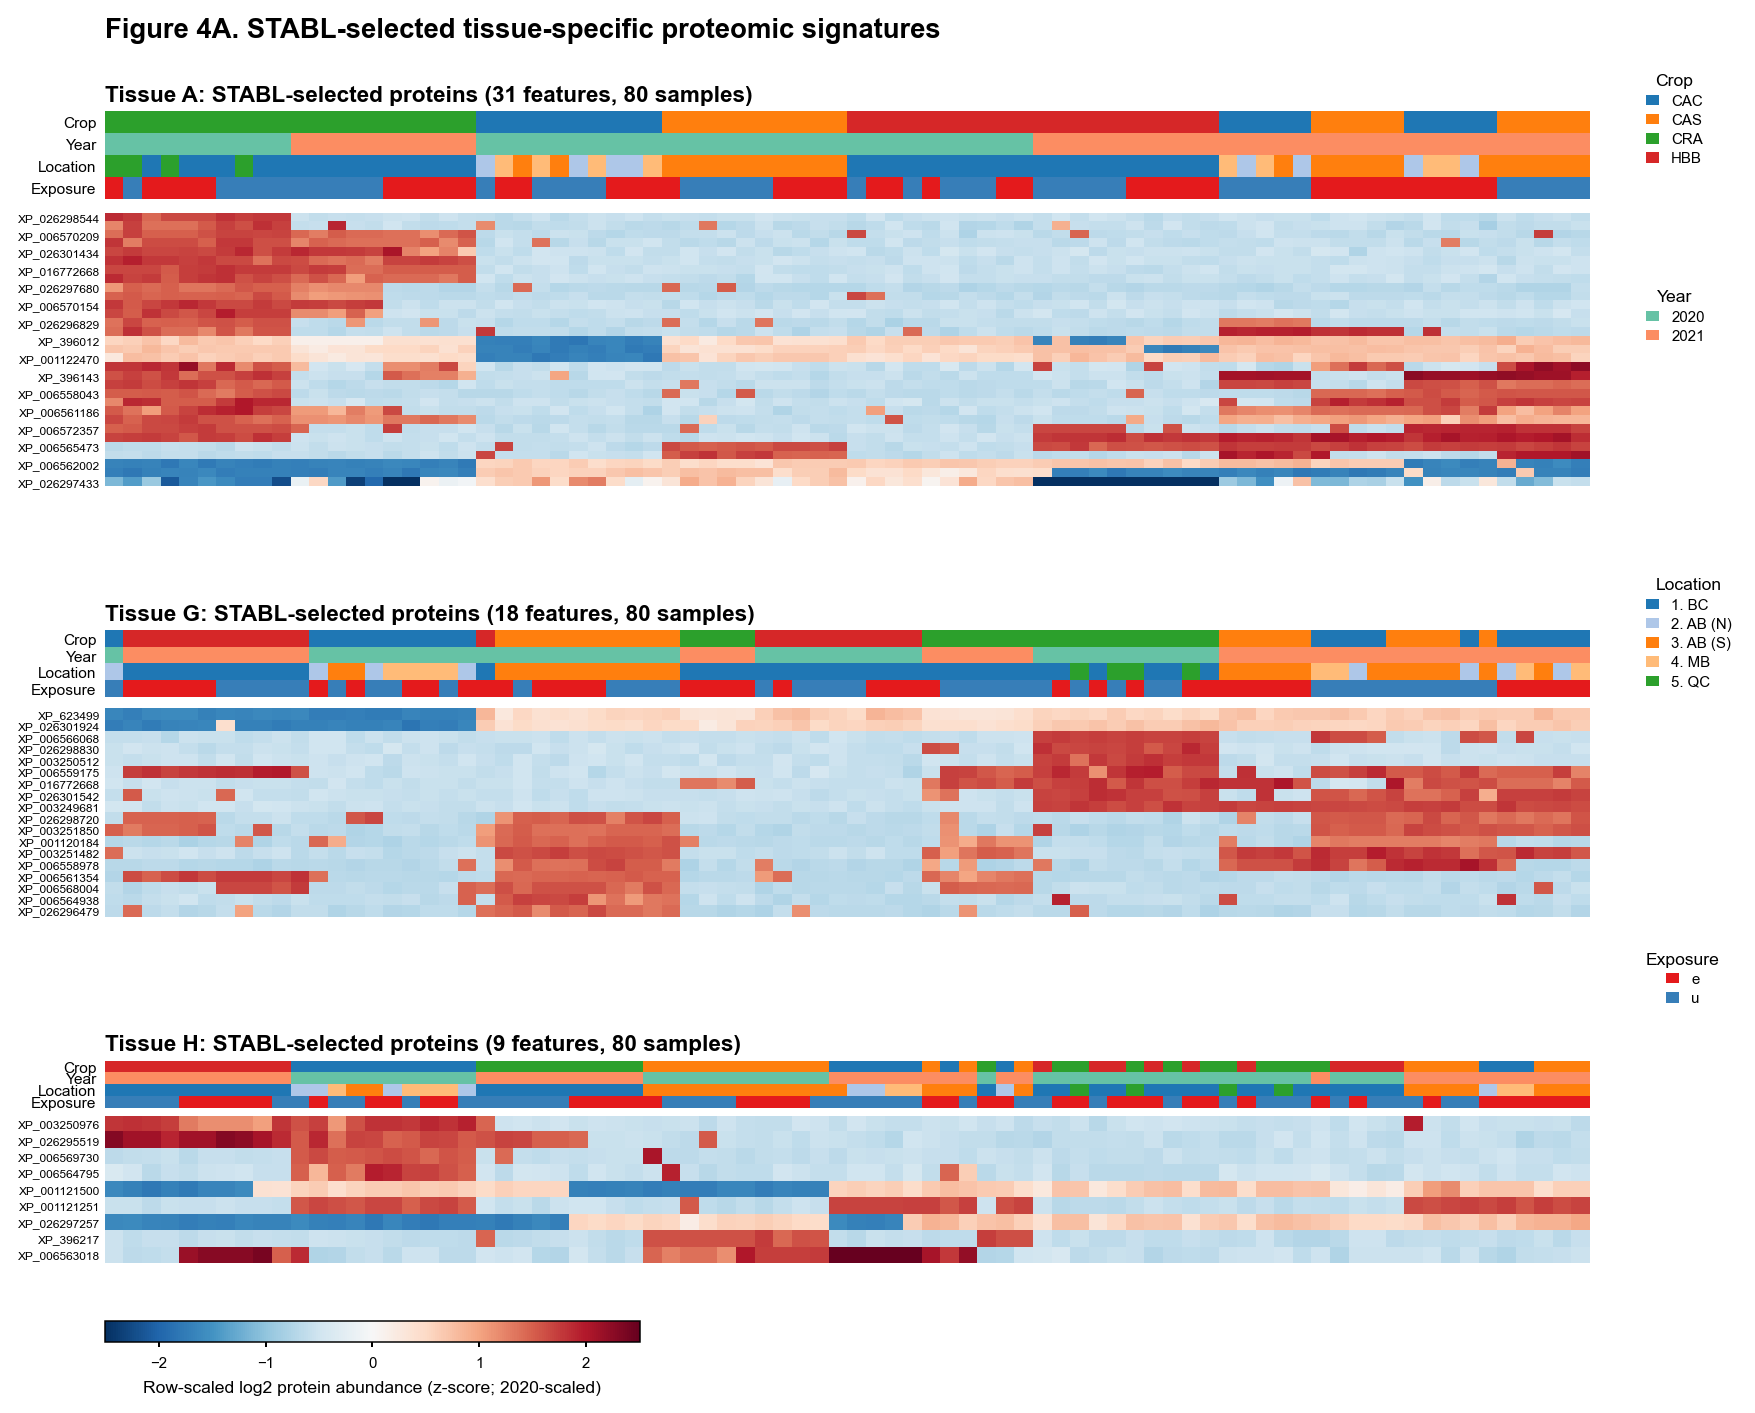

Saved Figure 4A:
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4A_STABL_tissue_specific_selected_protein_heatmap.png
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4A_STABL_tissue_specific_selected_protein_heatmap.pdf
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4A_STABL_tissue_specific_selected_protein_heatmap.svg


In [19]:
# ============================================================
# 5. Figure 4A: STABL-selected protein heatmap
# ============================================================

def save_stabl_feature_manifest():
    rows = []

    for tissue in TISSUES:
        d = stabl_heatmap_data[tissue]

        for rank, feature in enumerate(d["available_features"], start=1):
            rows.append({
                "tissue": tissue,
                "rank_in_heatmap_input": rank,
                "protein_id": feature,
            })

    feature_manifest = pd.DataFrame(rows)
    out_path = RESULTS_DIR / "Figure4A_STABL_heatmap_feature_manifest.csv"
    feature_manifest.to_csv(out_path, index=False)

    print("Saved full STABL feature list:")
    print(out_path)


def plot_figure4A_stabl_heatmap():
    panel_feature_counts = [
        stabl_heatmap_data[tissue]["Xz"].shape[0]
        for tissue in TISSUES
    ]

    # Moderated height ratios keep the figure readable but prevent one tissue
    # from dominating the layout.
    height_ratios = [max(1.0, np.sqrt(k)) for k in panel_feature_counts]

    fig = plt.figure(figsize=(11.0, 8.0), constrained_layout=False)

    outer = GridSpec(
        nrows=len(TISSUES),
        ncols=1,
        figure=fig,
        height_ratios=height_ratios,
        hspace=0.50,
        left=0.13,
        right=0.88,
        top=0.90,
        bottom=0.10,
    )

    last_im = None

    for i, tissue in enumerate(TISSUES):
        Xz = stabl_heatmap_data[tissue]["Xz"]
        sample_meta = stabl_heatmap_data[tissue]["sample_meta"]

        inner = GridSpecFromSubplotSpec(
            nrows=2,
            ncols=1,
            subplot_spec=outer[i],
            height_ratios=[0.32, 1.0],
            hspace=0.08,
        )

        ax_annot = fig.add_subplot(inner[0])
        ax_heat = fig.add_subplot(inner[1])

        ax_annot.set_title(
            f"Tissue {tissue}: STABL-selected proteins ({Xz.shape[0]} features, {Xz.shape[1]} samples)",
            loc="left",
            fontsize=9,
            fontweight="bold",
            pad=4,
        )

        draw_annotation_bars(ax_annot, sample_meta)
        last_im = draw_heatmap(ax_heat, Xz)

    cbar_ax = fig.add_axes([0.13, 0.045, 0.27, 0.015])
    cbar = fig.colorbar(last_im, cax=cbar_ax, orientation="horizontal")
    cbar.set_label("Row-scaled log2 protein abundance (z-score; 2020-scaled)", fontsize=7)
    cbar.ax.tick_params(labelsize=6, length=2)

    add_grouped_legend(fig)

    fig.suptitle(
        "Figure 4A. STABL-selected tissue-specific proteomic signatures",
        x=0.13,
        y=0.965,
        ha="left",
        fontsize=11,
        fontweight="bold",
    )

    return fig


save_stabl_feature_manifest()

fig4a = plot_figure4A_stabl_heatmap()

fig4a_png = RESULTS_DIR / "Figure4A_STABL_tissue_specific_selected_protein_heatmap.png"
fig4a_pdf = RESULTS_DIR / "Figure4A_STABL_tissue_specific_selected_protein_heatmap.pdf"
fig4a_svg = RESULTS_DIR / "Figure4A_STABL_tissue_specific_selected_protein_heatmap.svg"

fig4a.savefig(fig4a_png, dpi=600)
fig4a.savefig(fig4a_pdf)
fig4a.savefig(fig4a_svg)

plt.show()

print("Saved Figure 4A:")
print(fig4a_png)
print(fig4a_pdf)
print(fig4a_svg)


In [20]:
# ============================================================
# 6. Compute UMAP coordinates and separation metrics
# ============================================================

def compute_centroid_separation_ratio(embedding, labels):
    """
    Average distance between group centroids / average within-group distance.
    Higher values mean stronger descriptive separation.
    """
    labels = pd.Series(labels).astype(str).reset_index(drop=True)
    embedding = np.asarray(embedding)

    groups = sorted(labels.dropna().unique().tolist())

    if len(groups) < 2:
        return np.nan

    centroids = []
    within_distances = []

    for group in groups:
        idx = labels == group
        group_points = embedding[idx.values]

        if group_points.shape[0] == 0:
            continue

        centroid = group_points.mean(axis=0)
        centroids.append(centroid)

        distances = np.linalg.norm(group_points - centroid, axis=1)
        within_distances.extend(distances.tolist())

    if len(centroids) < 2:
        return np.nan

    centroids = np.vstack(centroids)

    between = pairwise_distances(centroids)
    between_values = between[np.triu_indices_from(between, k=1)]

    mean_between = np.mean(between_values)
    mean_within = np.mean(within_distances)

    if mean_within == 0:
        return np.nan

    return mean_between / mean_within


def compute_nearest_centroid_accuracy(embedding, labels):
    """
    Descriptive nearest-centroid accuracy in UMAP space.
    This is not a supervised model performance metric.
    """
    labels = pd.Series(labels).astype(str).reset_index(drop=True)
    embedding = np.asarray(embedding)

    groups = sorted(labels.dropna().unique().tolist())

    if len(groups) < 2:
        return np.nan

    centroids = {}

    for group in groups:
        idx = labels == group
        group_points = embedding[idx.values]

        if group_points.shape[0] > 0:
            centroids[group] = group_points.mean(axis=0)

    predictions = []

    for point in embedding:
        distances = {
            group: np.linalg.norm(point - centroid)
            for group, centroid in centroids.items()
        }

        pred_group = min(distances, key=distances.get)
        predictions.append(pred_group)

    predictions = pd.Series(predictions)

    return np.mean(predictions.values == labels.values)


def compute_umap_separation_metrics(embedding, sample_meta, label_col):
    labels = sample_meta[label_col].astype(str).reset_index(drop=True)
    embedding = np.asarray(embedding)

    unique_labels = sorted(labels.dropna().unique().tolist())

    if len(unique_labels) < 2 or len(unique_labels) >= embedding.shape[0]:
        silhouette = np.nan
    else:
        silhouette = silhouette_score(embedding, labels)

    centroid_ratio = compute_centroid_separation_ratio(embedding, labels)
    nearest_centroid_acc = compute_nearest_centroid_accuracy(embedding, labels)

    return {
        "label_col": label_col,
        "n_groups": len(unique_labels),
        "groups": ";".join(unique_labels),
        "silhouette": silhouette,
        "centroid_separation_ratio": centroid_ratio,
        "nearest_centroid_accuracy": nearest_centroid_acc,
    }


def run_umap_for_method_year_tissue(method, year, tissue):
    panel = method_panel_data[(method, year, tissue)]
    merged = panel["merged"].copy()
    Xz = panel["Xz"].copy()

    n_samples = Xz.shape[0]

    if n_samples < 3:
        raise ValueError(f"Not enough samples for UMAP: method={method}, year={year}, tissue={tissue}, n={n_samples}")

    n_neighbors = min(UMAP_N_NEIGHBORS, max(2, n_samples - 1))

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=UMAP_MIN_DIST,
        metric="euclidean",
        random_state=UMAP_RANDOM_STATE,
        n_jobs=1,
    )

    embedding = reducer.fit_transform(Xz.values)

    out_cols = ["sample_id", "crop", "tissue", "year", "source_year", "exposure", LOCATION_COL]
    umap_df = merged[out_cols].copy()

    umap_df["method"] = method
    umap_df["source_year"] = umap_df["source_year"].astype(int)
    umap_df["UMAP1"] = embedding[:, 0]
    umap_df["UMAP2"] = embedding[:, 1]
    umap_df["n_samples"] = n_samples
    umap_df["n_features"] = Xz.shape[1]
    umap_df["n_requested_features_from_file"] = len(panel["requested_features"])
    umap_df["n_missing_features"] = len(panel["missing_features"])
    umap_df["umap_fit_mode"] = "separate_fit_per_method_year_tissue"
    umap_df["feature_set_type"] = panel["feature_set_type"]
    umap_df["scaling_mode"] = panel["scaling_mode"]

    metric_rows = []

    for label_col in ["crop", LOCATION_COL]:
        metrics = compute_umap_separation_metrics(
            embedding=embedding,
            sample_meta=merged,
            label_col=label_col,
        )

        metrics["method"] = method
        metrics["year"] = year
        metrics["tissue"] = tissue
        metrics["n_features"] = Xz.shape[1]
        metrics["n_requested_features_from_file"] = len(panel["requested_features"])
        metrics["n_missing_features"] = len(panel["missing_features"])
        metrics["n_samples"] = n_samples
        metrics["scaling_mode"] = panel["scaling_mode"]
        metrics["feature_set_type"] = panel["feature_set_type"]

        metric_rows.append(metrics)

    metric_df = pd.DataFrame(metric_rows)

    return umap_df, metric_df


all_umap_frames = []
all_metric_frames = []

for method in METHODS:
    for year in YEARS:
        for tissue in TISSUES:
            umap_df, metric_df = run_umap_for_method_year_tissue(method, year, tissue)

            all_umap_frames.append(umap_df)
            all_metric_frames.append(metric_df)

umap_all = pd.concat(all_umap_frames, ignore_index=True)
umap_metrics = pd.concat(all_metric_frames, ignore_index=True)

umap_coord_path = RESULTS_DIR / "Figure4B_STABL_vs_LIMMA_year_specific_UMAP_coordinates.csv"
umap_metric_path = RESULTS_DIR / "Figure4C_STABL_vs_LIMMA_year_specific_UMAP_separation_metrics_long.csv"

umap_all.to_csv(umap_coord_path, index=False)
umap_metrics.to_csv(umap_metric_path, index=False)

print("Saved UMAP coordinates:")
print(umap_coord_path)

print("\nSaved UMAP separation metrics:")
print(umap_metric_path)

print("\nUMAP feature counts by method/year/tissue:")
display(
    umap_all.groupby(["method", "source_year", "tissue"])
    .agg(
        n_samples=("sample_id", "nunique"),
        n_features=("n_features", "first"),
        n_requested_features_from_file=("n_requested_features_from_file", "first"),
        n_missing_features=("n_missing_features", "first"),
        n_crops=("crop", "nunique"),
        n_locations=(LOCATION_COL, "nunique"),
        scaling_mode=("scaling_mode", "first"),
        feature_set_type=("feature_set_type", "first"),
    )
    .reset_index()
)

display(umap_metrics)


Saved UMAP coordinates:
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4B_STABL_vs_LIMMA_year_specific_UMAP_coordinates.csv

Saved UMAP separation metrics:
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4C_STABL_vs_LIMMA_year_specific_UMAP_separation_metrics_long.csv

UMAP feature counts by method/year/tissue:


,method,source_year,tissue,n_samples,n_features,n_requested_features_from_file,n_missing_features,n_crops,n_locations,scaling_mode,feature_set_type
0,LIMMA,2020,A,40,83,83,0,4,5,within_method_year_tissue_panel,year_specific_LIMMA_top20_per_contrast_combine...
1,LIMMA,2020,G,40,93,93,0,4,5,within_method_year_tissue_panel,year_specific_LIMMA_top20_per_contrast_combine...
2,LIMMA,2020,H,40,76,76,0,4,5,within_method_year_tissue_panel,year_specific_LIMMA_top20_per_contrast_combine...
3,LIMMA,2021,A,40,80,80,0,4,4,within_method_year_tissue_panel,year_specific_LIMMA_top20_per_contrast_combine...
4,LIMMA,2021,G,40,83,83,0,4,4,within_method_year_tissue_panel,year_specific_LIMMA_top20_per_contrast_combine...
5,LIMMA,2021,H,40,84,84,0,4,4,within_method_year_tissue_panel,year_specific_LIMMA_top20_per_contrast_combine...
6,STABL,2020,A,40,31,31,0,4,5,within_method_year_tissue_panel,stabl_selected_proteins
7,STABL,2020,G,40,18,18,0,4,5,within_method_year_tissue_panel,stabl_selected_proteins
8,STABL,2020,H,40,9,9,0,4,5,within_method_year_tissue_panel,stabl_selected_proteins
9,STABL,2021,A,40,31,31,0,4,4,within_method_year_tissue_panel,stabl_selected_proteins


,label_col,n_groups,groups,silhouette,centroid_separation_ratio,nearest_centroid_accuracy,method,year,tissue,n_features,n_requested_features_from_file,n_missing_features,n_samples,scaling_mode,feature_set_type
0,crop,4,CAC;CAS;CRA;HBB,0.916596,42.806203,1.000,STABL,2020,A,31,31,0,40,within_method_year_tissue_panel,stabl_selected_proteins
1,geo_cluster_region,5,1. BC;2. AB (N);3. AB (S);4. MB;5. QC,0.128241,3.558858,0.750,STABL,2020,A,31,31,0,40,within_method_year_tissue_panel,stabl_selected_proteins
2,crop,4,CAC;CAS;CRA;HBB,0.962962,56.598374,1.000,STABL,2020,G,18,18,0,40,within_method_year_tissue_panel,stabl_selected_proteins
3,geo_cluster_region,5,1. BC;2. AB (N);3. AB (S);4. MB;5. QC,0.204934,2.884229,0.700,STABL,2020,G,18,18,0,40,within_method_year_tissue_panel,stabl_selected_proteins
4,crop,4,CAC;CAS;CRA;HBB,0.858832,20.865160,0.975,STABL,2020,H,9,9,0,40,within_method_year_tissue_panel,stabl_selected_proteins
5,geo_cluster_region,5,1. BC;2. AB (N);3. AB (S);4. MB;5. QC,0.187288,3.055165,0.725,STABL,2020,H,9,9,0,40,within_method_year_tissue_panel,stabl_selected_proteins
6,crop,4,CAC;CAS;CRA;HBB,0.517917,34.266988,0.875,STABL,2021,A,31,31,0,40,within_method_year_tissue_panel,stabl_selected_proteins
7,geo_cluster_region,4,1. BC;2. AB (N);3. AB (S);4. MB,0.117943,2.049922,0.750,STABL,2021,A,31,31,0,40,within_method_year_tissue_panel,stabl_selected_proteins
8,crop,4,CAC;CAS;CRA;HBB,0.332786,4.074981,0.750,STABL,2021,G,18,18,0,40,within_method_year_tissue_panel,stabl_selected_proteins
9,geo_cluster_region,4,1. BC;2. AB (N);3. AB (S);4. MB,0.158571,2.868498,0.650,STABL,2021,G,18,18,0,40,within_method_year_tissue_panel,stabl_selected_proteins


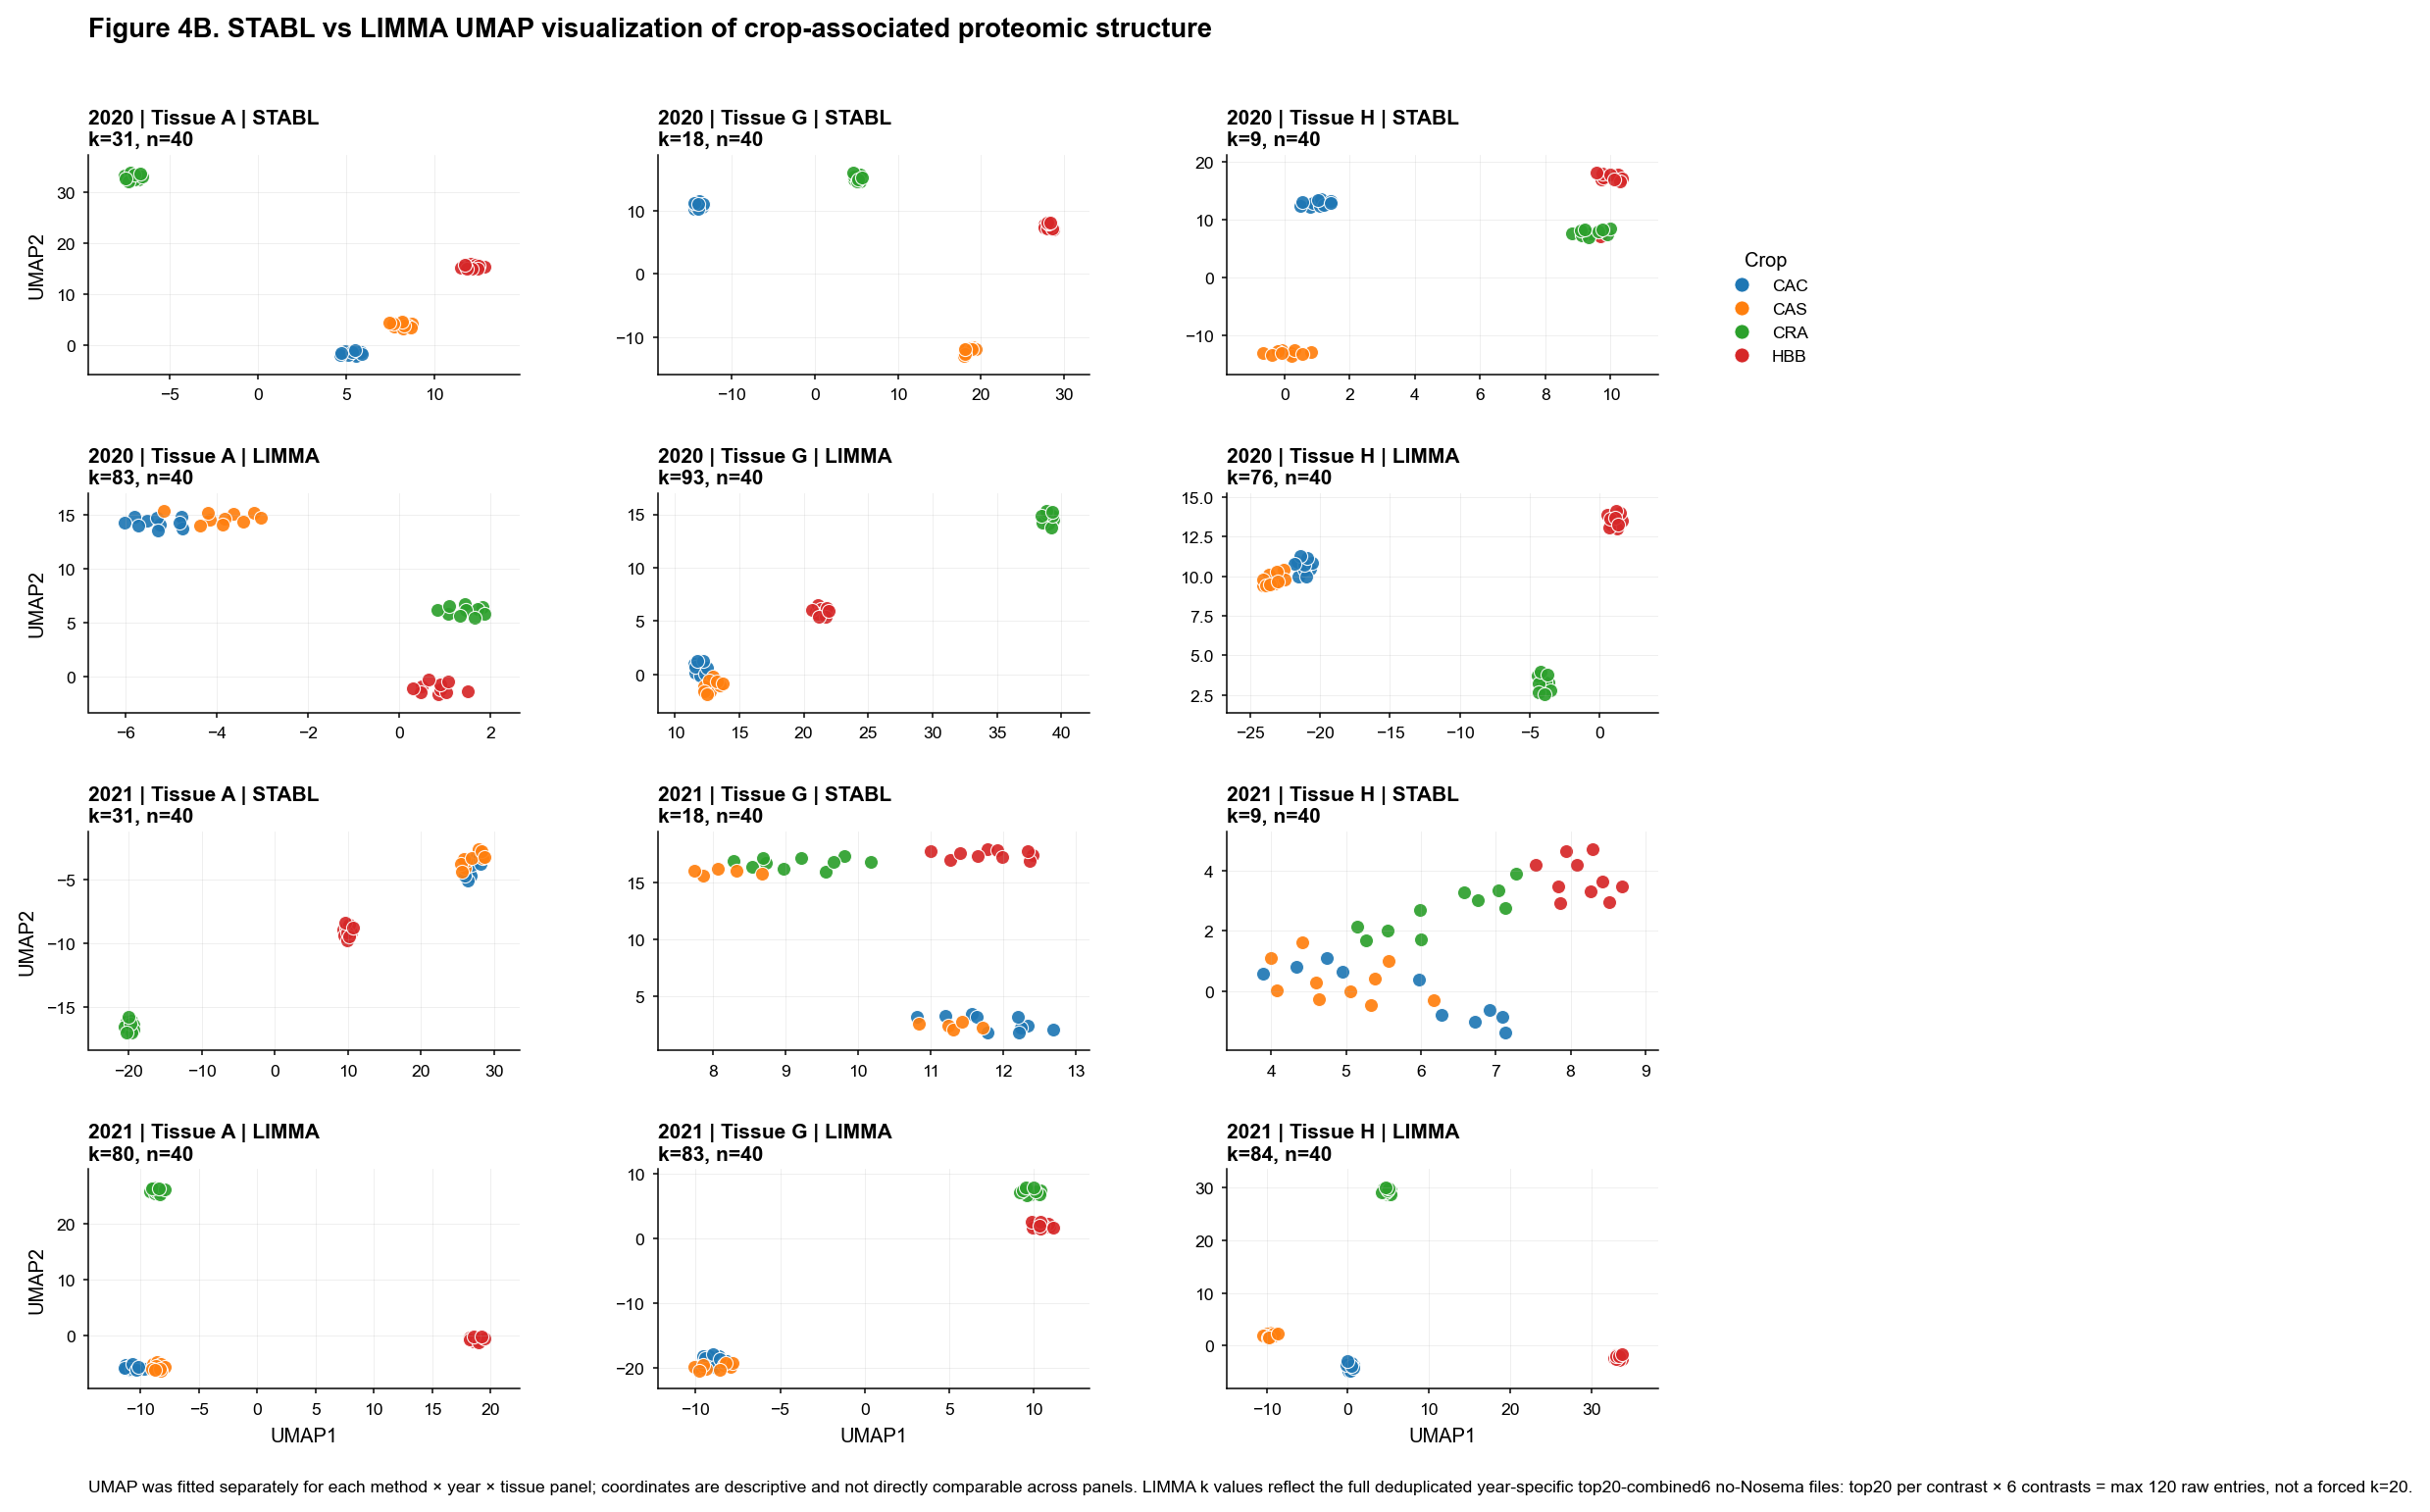

Saved Figure 4B:
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4B_STABL_vs_LIMMA_year_specific_UMAP_crop.png
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4B_STABL_vs_LIMMA_year_specific_UMAP_crop.pdf
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4B_STABL_vs_LIMMA_year_specific_UMAP_crop.svg


In [21]:
# ============================================================
# 7. Figure 4B: STABL vs LIMMA UMAP comparison
# ============================================================

def get_panel_axis_limits(d):
    x = d["UMAP1"].to_numpy()
    y = d["UMAP2"].to_numpy()

    x_range = np.nanmax(x) - np.nanmin(x)
    y_range = np.nanmax(y) - np.nanmin(y)

    xpad = max(0.35, x_range * 0.10)
    ypad = max(0.35, y_range * 0.10)

    return (
        (np.nanmin(x) - xpad, np.nanmax(x) + xpad),
        (np.nanmin(y) - ypad, np.nanmax(y) + ypad),
    )


def clean_umap_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both", labelsize=7, length=2, width=0.6)

    ax.set_xlabel("UMAP1", fontsize=8)
    ax.set_ylabel("UMAP2", fontsize=8)

    ax.grid(True, linewidth=0.35, alpha=0.22)


def plot_umap_points(ax, d, color_col, palette):
    for _, row in d.iterrows():
        label = str(row[color_col])

        ax.scatter(
            row["UMAP1"],
            row["UMAP2"],
            s=32,
            alpha=0.92,
            color=palette.get(label, "lightgray"),
            edgecolor="white",
            linewidth=0.45,
        )


def add_color_legend(fig, color_title, palette, x=0.895, y=0.86):
    handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            label=str(label),
            markerfacecolor=color,
            markeredgecolor="white",
            markeredgewidth=0.3,
            markersize=6,
        )
        for label, color in palette.items()
    ]

    fig.legend(
        handles=handles,
        title=color_title,
        loc="upper left",
        bbox_to_anchor=(x, y),
        frameon=False,
        fontsize=7,
        title_fontsize=8,
    )


def plot_figure4B_stabl_vs_limma_umap(umap_all):
    """
    Rows: year × method
    Columns: tissue

    This keeps the LIMMA code structure close to the original 2 × 3 year/tissue UMAP,
    while adding STABL for direct comparison.
    """
    row_specs = [
        (2020, "STABL"),
        (2020, "LIMMA"),
        (2021, "STABL"),
        (2021, "LIMMA"),
    ]

    fig, axes = plt.subplots(
        nrows=len(row_specs),
        ncols=len(TISSUES),
        figsize=(11.4, 9.2),
        constrained_layout=False,
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.86,
        bottom=0.12,
        top=0.88,
        wspace=0.32,
        hspace=0.54,
    )

    for r, (year, method) in enumerate(row_specs):
        for c, tissue in enumerate(TISSUES):
            ax = axes[r, c]

            d = umap_all[
                (umap_all["method"].astype(str) == method)
                & (umap_all["source_year"].astype(int) == int(year))
                & (umap_all["tissue"].astype(str) == tissue)
            ].copy()

            if d.empty:
                ax.text(
                    0.5,
                    0.5,
                    f"No samples\n{year}, {method}, Tissue {tissue}",
                    ha="center",
                    va="center",
                    fontsize=9,
                )
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            plot_umap_points(
                ax=ax,
                d=d,
                color_col="crop",
                palette=crop_palette,
            )

            xlim, ylim = get_panel_axis_limits(d)
            ax.set_xlim(*xlim)
            ax.set_ylim(*ylim)

            clean_umap_axis(ax)

            if r != len(row_specs) - 1:
                ax.set_xlabel("")
            if c != 0:
                ax.set_ylabel("")

            k = int(d["n_features"].iloc[0])
            n = int(d["n_samples"].iloc[0])

            ax.set_title(
                f"{year} | Tissue {tissue} | {method}\n"
                f"k={k}, n={n}",
                loc="left",
                fontsize=8.4,
                fontweight="bold",
                pad=4,
            )

    add_color_legend(fig, "Crop", crop_palette, x=0.885, y=0.83)

    fig.text(
        0.08,
        0.055,
        "UMAP was fitted separately for each method × year × tissue panel; coordinates are descriptive and not directly comparable across panels. "
        "LIMMA k values reflect the full deduplicated year-specific top20-combined6 no-Nosema files: top20 per contrast × 6 contrasts = max 120 raw entries, not a forced k=20.",
        ha="left",
        va="bottom",
        fontsize=7,
    )

    fig.suptitle(
        "Figure 4B. STABL vs LIMMA UMAP visualization of crop-associated proteomic structure",
        x=0.08,
        y=0.965,
        ha="left",
        fontsize=11,
        fontweight="bold",
    )

    return fig


fig4b = plot_figure4B_stabl_vs_limma_umap(umap_all)

fig4b_png = RESULTS_DIR / "Figure4B_STABL_vs_LIMMA_year_specific_UMAP_crop.png"
fig4b_pdf = RESULTS_DIR / "Figure4B_STABL_vs_LIMMA_year_specific_UMAP_crop.pdf"
fig4b_svg = RESULTS_DIR / "Figure4B_STABL_vs_LIMMA_year_specific_UMAP_crop.svg"

fig4b.savefig(fig4b_png, dpi=600, bbox_inches="tight")
fig4b.savefig(fig4b_pdf, bbox_inches="tight")
fig4b.savefig(fig4b_svg, bbox_inches="tight")

plt.show()

print("Saved Figure 4B:")
print(fig4b_png)
print(fig4b_pdf)
print(fig4b_svg)


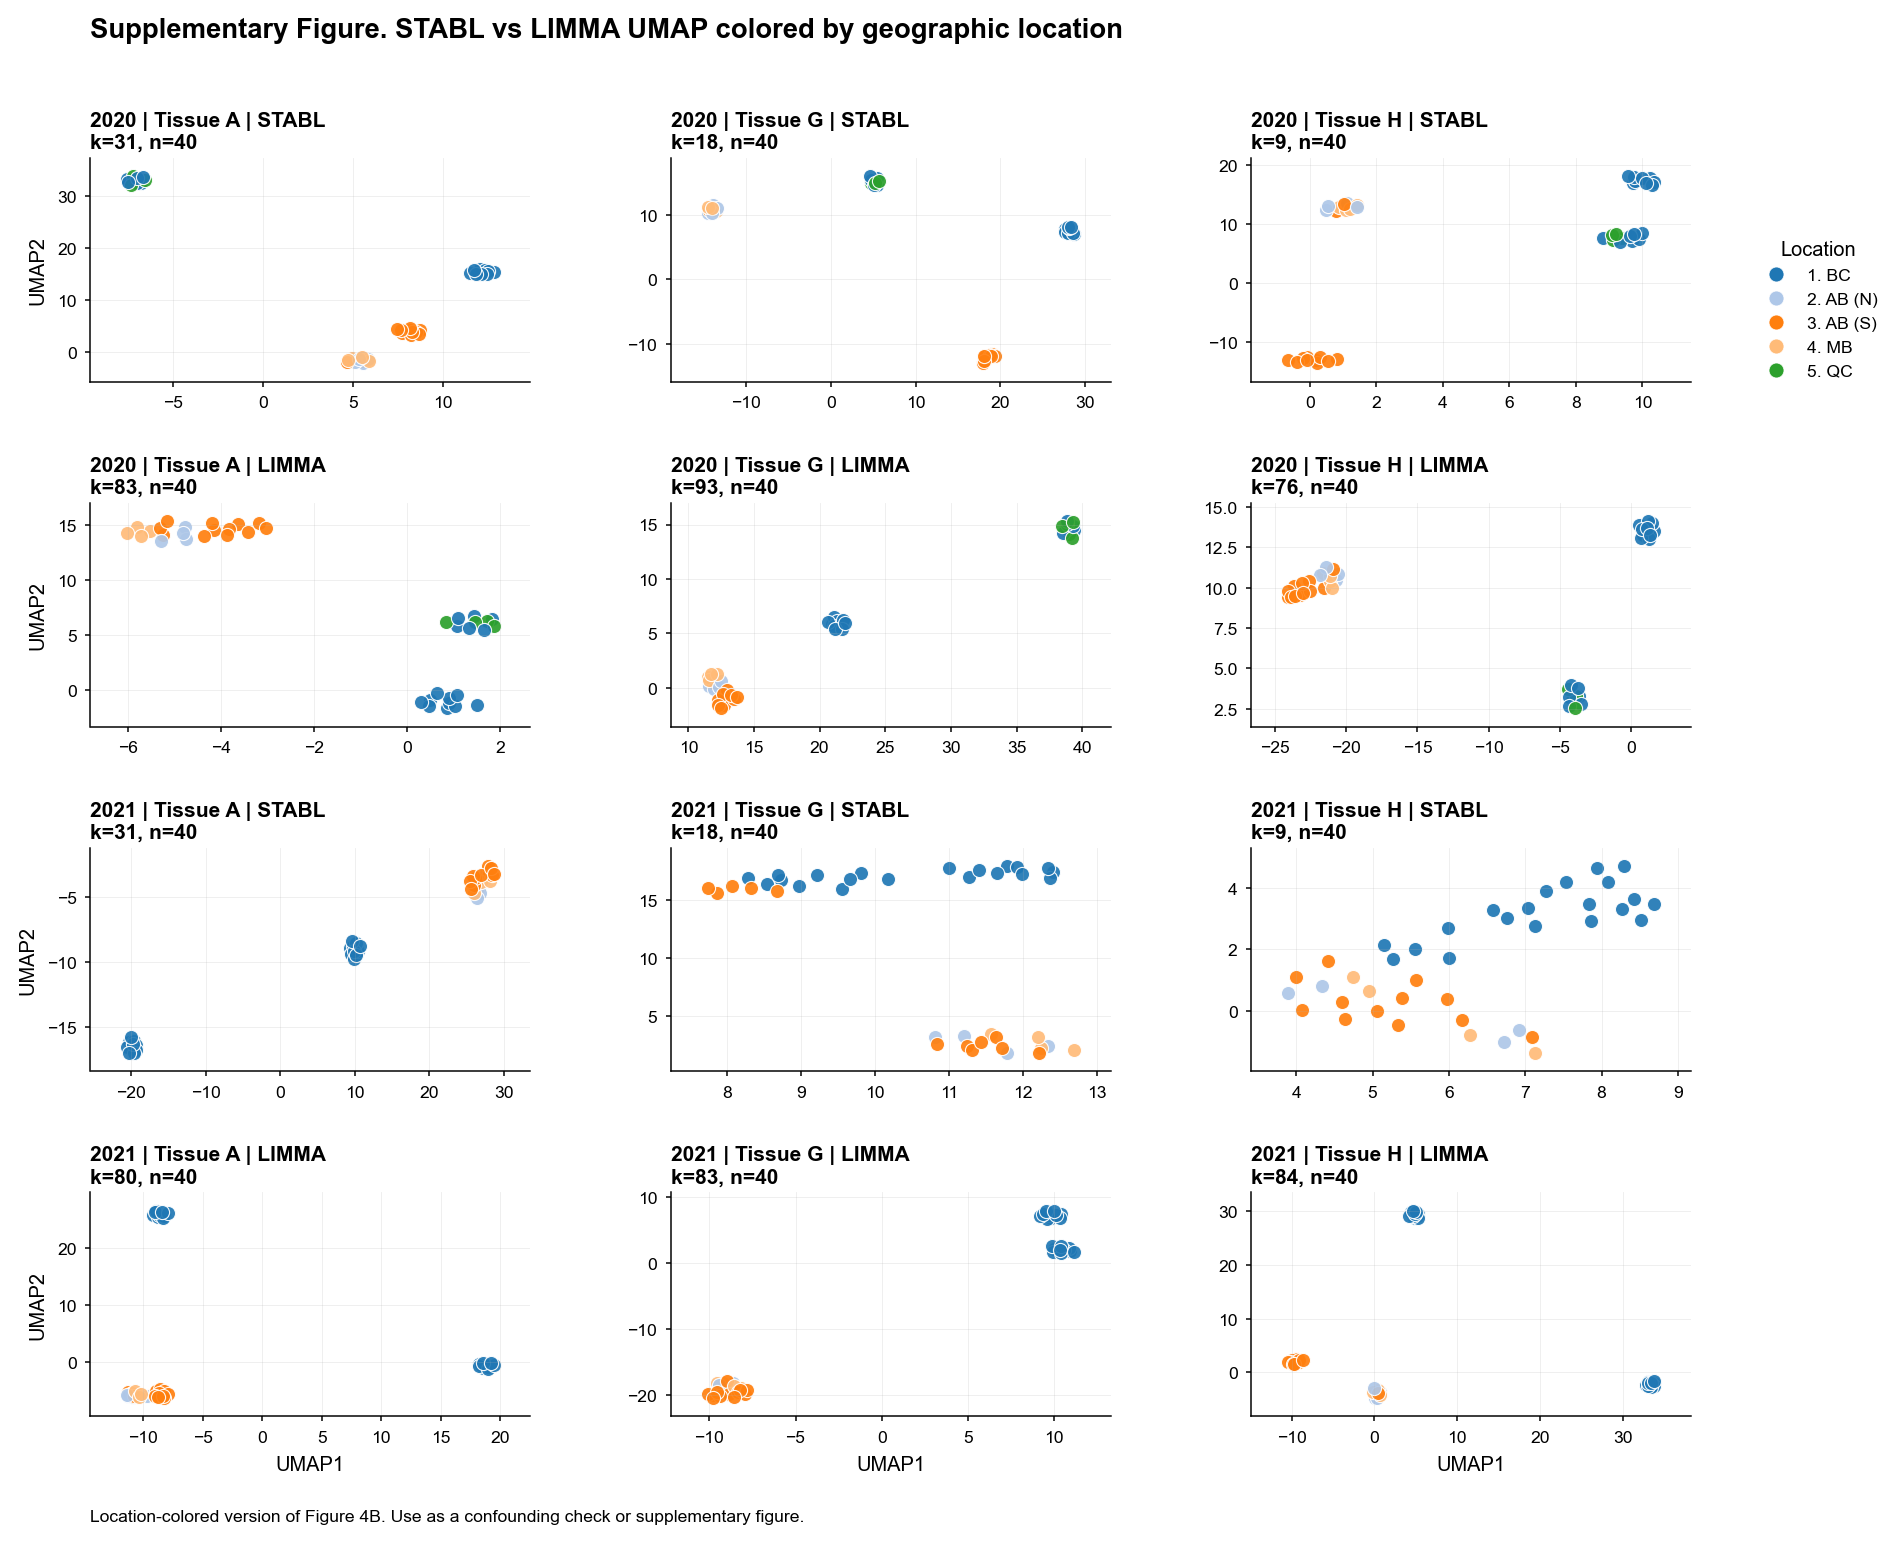

Saved supplementary location check:
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Supplementary_STABL_vs_LIMMA_year_specific_UMAP_location.png
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Supplementary_STABL_vs_LIMMA_year_specific_UMAP_location.pdf
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Supplementary_STABL_vs_LIMMA_year_specific_UMAP_location.svg


In [22]:
# ============================================================
# 8. Figure 4B optional check: same UMAP colored by location
# ============================================================
# This optional figure helps check whether the apparent crop structure may overlap
# with geographic location structure. It is often better as supplementary material.

def plot_figure4B_location_check(umap_all):
    row_specs = [
        (2020, "STABL"),
        (2020, "LIMMA"),
        (2021, "STABL"),
        (2021, "LIMMA"),
    ]

    fig, axes = plt.subplots(
        nrows=len(row_specs),
        ncols=len(TISSUES),
        figsize=(11.4, 9.2),
        constrained_layout=False,
    )

    fig.subplots_adjust(
        left=0.08,
        right=0.86,
        bottom=0.12,
        top=0.88,
        wspace=0.32,
        hspace=0.54,
    )

    for r, (year, method) in enumerate(row_specs):
        for c, tissue in enumerate(TISSUES):
            ax = axes[r, c]

            d = umap_all[
                (umap_all["method"].astype(str) == method)
                & (umap_all["source_year"].astype(int) == int(year))
                & (umap_all["tissue"].astype(str) == tissue)
            ].copy()

            if d.empty:
                ax.text(0.5, 0.5, f"No samples\n{year}, {method}, Tissue {tissue}",
                        ha="center", va="center", fontsize=9)
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            plot_umap_points(
                ax=ax,
                d=d,
                color_col=LOCATION_COL,
                palette=location_palette,
            )

            xlim, ylim = get_panel_axis_limits(d)
            ax.set_xlim(*xlim)
            ax.set_ylim(*ylim)

            clean_umap_axis(ax)

            if r != len(row_specs) - 1:
                ax.set_xlabel("")
            if c != 0:
                ax.set_ylabel("")

            k = int(d["n_features"].iloc[0])
            n = int(d["n_samples"].iloc[0])

            ax.set_title(
                f"{year} | Tissue {tissue} | {method}\n"
                f"k={k}, n={n}",
                loc="left",
                fontsize=8.4,
                fontweight="bold",
                pad=4,
            )

    add_color_legend(fig, "Location", location_palette, x=0.885, y=0.84)

    fig.text(
        0.08,
        0.055,
        "Location-colored version of Figure 4B. Use as a confounding check or supplementary figure.",
        ha="left",
        va="bottom",
        fontsize=7,
    )

    fig.suptitle(
        "Supplementary Figure. STABL vs LIMMA UMAP colored by geographic location",
        x=0.08,
        y=0.965,
        ha="left",
        fontsize=11,
        fontweight="bold",
    )

    return fig


fig4b_location = plot_figure4B_location_check(umap_all)

fig4b_location_png = RESULTS_DIR / "Supplementary_STABL_vs_LIMMA_year_specific_UMAP_location.png"
fig4b_location_pdf = RESULTS_DIR / "Supplementary_STABL_vs_LIMMA_year_specific_UMAP_location.pdf"
fig4b_location_svg = RESULTS_DIR / "Supplementary_STABL_vs_LIMMA_year_specific_UMAP_location.svg"

fig4b_location.savefig(fig4b_location_png, dpi=600, bbox_inches="tight")
fig4b_location.savefig(fig4b_location_pdf, bbox_inches="tight")
fig4b_location.savefig(fig4b_location_svg, bbox_inches="tight")

plt.show()

print("Saved supplementary location check:")
print(fig4b_location_png)
print(fig4b_location_pdf)
print(fig4b_location_svg)


In [23]:
# ============================================================
# 9. Figure 4C: Quantitative STABL vs LIMMA separation summary
# ============================================================

def prepare_separation_summary(umap_metrics):
    df = umap_metrics.copy()

    df["label_type"] = df["label_col"].astype(str).replace({
        "crop": "Crop",
        LOCATION_COL: "Location",
    })

    keep_cols = [
        "method",
        "year",
        "tissue",
        "label_type",
        "n_features",
        "n_samples",
        "n_groups",
        "silhouette",
        "centroid_separation_ratio",
        "nearest_centroid_accuracy",
    ]

    df = df[keep_cols].copy()

    wide = df.pivot_table(
        index=["method", "year", "tissue", "n_features", "n_samples"],
        columns="label_type",
        values=[
            "silhouette",
            "centroid_separation_ratio",
            "nearest_centroid_accuracy",
        ],
        aggfunc="first",
    )

    wide.columns = [f"{metric}_{label}" for metric, label in wide.columns]
    wide = wide.reset_index()

    wide["silhouette_delta_crop_minus_location"] = (
        wide["silhouette_Crop"] - wide["silhouette_Location"]
    )

    wide["centroid_ratio_delta_crop_minus_location"] = (
        wide["centroid_separation_ratio_Crop"] -
        wide["centroid_separation_ratio_Location"]
    )

    wide["nearest_centroid_accuracy_delta_crop_minus_location"] = (
        wide["nearest_centroid_accuracy_Crop"] -
        wide["nearest_centroid_accuracy_Location"]
    )

    return wide


separation_summary = prepare_separation_summary(umap_metrics)

summary_csv_path = RESULTS_DIR / "Figure4C_STABL_vs_LIMMA_year_specific_separation_summary.csv"
separation_summary.to_csv(summary_csv_path, index=False)

print("Saved separation summary:")
print(summary_csv_path)

display(separation_summary)


Saved separation summary:
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4C_STABL_vs_LIMMA_year_specific_separation_summary.csv


,method,year,tissue,n_features,n_samples,centroid_separation_ratio_Crop,centroid_separation_ratio_Location,nearest_centroid_accuracy_Crop,nearest_centroid_accuracy_Location,silhouette_Crop,silhouette_Location,silhouette_delta_crop_minus_location,centroid_ratio_delta_crop_minus_location,nearest_centroid_accuracy_delta_crop_minus_location
0,LIMMA,2020,A,83,40,18.809212,4.766124,0.975,0.725,0.657300,0.172738,0.484561,14.043087,0.250
1,LIMMA,2020,G,93,40,31.912573,3.960183,1.000,0.800,0.752980,0.120863,0.632117,27.952391,0.200
2,LIMMA,2020,H,76,40,31.707594,5.182488,1.000,0.700,0.786207,0.181440,0.604768,26.525106,0.300
3,LIMMA,2021,A,80,40,50.874213,1.268038,1.000,0.900,0.798255,0.243617,0.554637,49.606175,0.100
4,LIMMA,2021,G,83,40,34.344728,9.112897,0.975,0.900,0.568321,0.455593,0.112728,25.231830,0.075
5,LIMMA,2021,H,84,40,62.118566,1.429066,1.000,0.850,0.953310,0.277577,0.675733,60.689500,0.150
6,STABL,2020,A,31,40,42.806203,3.558858,1.000,0.750,0.916596,0.128241,0.788355,39.247345,0.250
7,STABL,2020,G,18,40,56.598374,2.884229,1.000,0.700,0.962962,0.204934,0.758028,53.714145,0.300
8,STABL,2020,H,9,40,20.865160,3.055165,0.975,0.725,0.858832,0.187288,0.671544,17.809995,0.250
9,STABL,2021,A,31,40,34.266988,2.049922,0.875,0.750,0.517917,0.117943,0.399974,32.217066,0.125


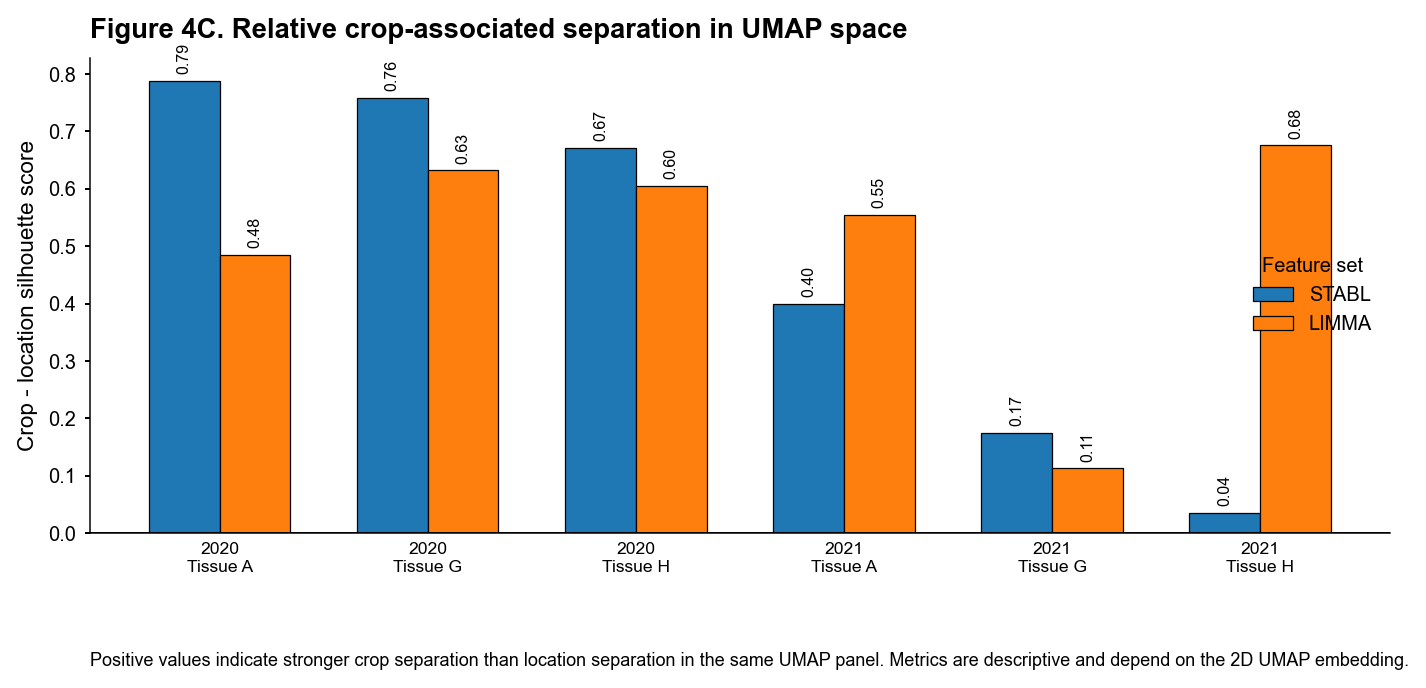

Saved Figure 4C bar plot:
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4C_STABL_vs_LIMMA_year_specific_silhouette_delta_bar.png
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4C_STABL_vs_LIMMA_year_specific_silhouette_delta_bar.pdf
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4C_STABL_vs_LIMMA_year_specific_silhouette_delta_bar.svg


In [24]:
# ============================================================
# 10. Figure 4C option 1: silhouette delta bar plot
# ============================================================

def plot_figure4C_silhouette_delta_bar(separation_summary):
    df = separation_summary.copy()
    df["method"] = df["method"].astype(str)
    df["year"] = df["year"].astype(int)
    df["tissue"] = df["tissue"].astype(str)

    x_labels = []
    row_keys = []

    for year in YEARS:
        for tissue in TISSUES:
            row_keys.append((year, tissue))
            x_labels.append(f"{year}\nTissue {tissue}")

    x = np.arange(len(row_keys))
    width = 0.34

    fig, ax = plt.subplots(figsize=(8.4, 4.4))

    for j, method in enumerate(METHODS):
        vals = []

        for year, tissue in row_keys:
            row = df[
                (df["method"] == method)
                & (df["year"] == int(year))
                & (df["tissue"] == tissue)
            ]

            if row.empty:
                vals.append(np.nan)
            else:
                vals.append(float(row["silhouette_delta_crop_minus_location"].iloc[0]))

        offset = (j - 0.5) * width

        ax.bar(
            x + offset,
            vals,
            width,
            label=method,
            edgecolor="black",
            linewidth=0.5,
        )

        for i, value in enumerate(vals):
            if pd.isna(value):
                continue

            y_offset = 0.012 if value >= 0 else -0.018

            ax.text(
                x[i] + offset,
                value + y_offset,
                f"{value:.2f}",
                ha="center",
                va="bottom" if value >= 0 else "top",
                fontsize=6.4,
                rotation=90,
            )

    ax.axhline(0, color="black", linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=7)

    ax.set_ylabel("Crop - location silhouette score", fontsize=9)

    ax.set_title(
        "Figure 4C. Relative crop-associated separation in UMAP space",
        loc="left",
        fontsize=11,
        fontweight="bold",
        pad=8,
    )

    ax.tick_params(axis="y", labelsize=8, length=2)
    ax.tick_params(axis="x", length=0)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        frameon=False,
        fontsize=8,
        title="Feature set",
        title_fontsize=8,
        loc="best",
    )

    ax.text(
        0.0,
        -0.25,
        "Positive values indicate stronger crop separation than location separation in the same UMAP panel. "
        "Metrics are descriptive and depend on the 2D UMAP embedding.",
        transform=ax.transAxes,
        fontsize=7.2,
        ha="left",
        va="top",
    )

    fig.subplots_adjust(left=0.12, right=0.98, top=0.88, bottom=0.28)

    return fig


fig4c_bar = plot_figure4C_silhouette_delta_bar(separation_summary)

fig4c_bar_png = RESULTS_DIR / "Figure4C_STABL_vs_LIMMA_year_specific_silhouette_delta_bar.png"
fig4c_bar_pdf = RESULTS_DIR / "Figure4C_STABL_vs_LIMMA_year_specific_silhouette_delta_bar.pdf"
fig4c_bar_svg = RESULTS_DIR / "Figure4C_STABL_vs_LIMMA_year_specific_silhouette_delta_bar.svg"

fig4c_bar.savefig(fig4c_bar_png, dpi=600)
fig4c_bar.savefig(fig4c_bar_pdf)
fig4c_bar.savefig(fig4c_bar_svg)

plt.show()

print("Saved Figure 4C bar plot:")
print(fig4c_bar_png)
print(fig4c_bar_pdf)
print(fig4c_bar_svg)


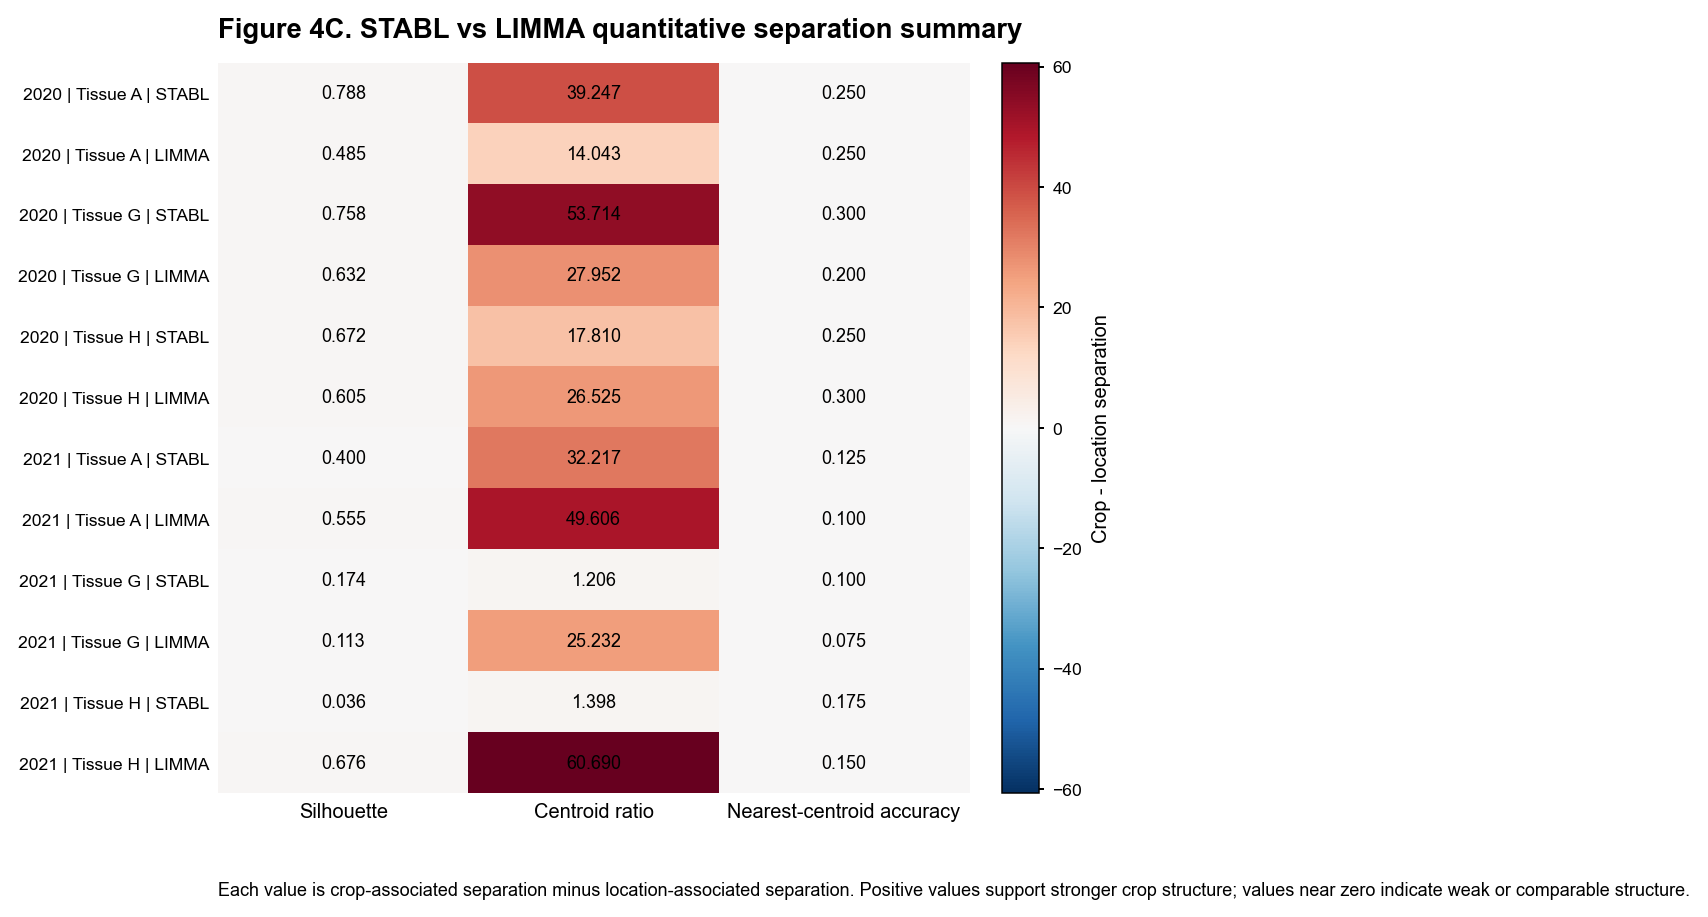

Saved Figure 4C heatmap:
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4C_STABL_vs_LIMMA_year_specific_delta_heatmap.png
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4C_STABL_vs_LIMMA_year_specific_delta_heatmap.pdf
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4C_STABL_vs_LIMMA_year_specific_delta_heatmap.svg


In [25]:
# ============================================================
# 11. Figure 4C option 2: all-metric delta heatmap
# ============================================================

def prepare_delta_heatmap_matrix(separation_summary):
    df = separation_summary.copy()
    df["method"] = df["method"].astype(str)
    df["year"] = df["year"].astype(int)
    df["tissue"] = df["tissue"].astype(str)

    rows = []

    for year in YEARS:
        for tissue in TISSUES:
            for method in METHODS:
                row = df[
                    (df["year"] == int(year))
                    & (df["tissue"] == tissue)
                    & (df["method"] == method)
                ]

                if row.empty:
                    rows.append({
                        "row_label": f"{year} | Tissue {tissue} | {method}",
                        "Silhouette": np.nan,
                        "Centroid ratio": np.nan,
                        "Nearest-centroid accuracy": np.nan,
                    })
                else:
                    row = row.iloc[0]
                    rows.append({
                        "row_label": f"{year} | Tissue {tissue} | {method}",
                        "Silhouette": row["silhouette_delta_crop_minus_location"],
                        "Centroid ratio": row["centroid_ratio_delta_crop_minus_location"],
                        "Nearest-centroid accuracy": row["nearest_centroid_accuracy_delta_crop_minus_location"],
                    })

    out = pd.DataFrame(rows).set_index("row_label")

    return out


def plot_figure4C_delta_heatmap(separation_summary):
    delta_df = prepare_delta_heatmap_matrix(separation_summary)
    values = delta_df.values.astype(float)

    max_abs = np.nanmax(np.abs(values))

    if not np.isfinite(max_abs) or max_abs == 0:
        max_abs = 1.0

    fig, ax = plt.subplots(figsize=(8.0, 5.8))

    im = ax.imshow(
        values,
        aspect="auto",
        cmap="RdBu_r",
        vmin=-max_abs,
        vmax=max_abs,
    )

    ax.set_xticks(np.arange(delta_df.shape[1]))
    ax.set_xticklabels(delta_df.columns, fontsize=8)

    ax.set_yticks(np.arange(delta_df.shape[0]))
    ax.set_yticklabels(delta_df.index, fontsize=7)

    ax.tick_params(axis="both", length=0)

    for i in range(delta_df.shape[0]):
        for j in range(delta_df.shape[1]):
            value = values[i, j]

            if pd.isna(value):
                text = "NA"
            else:
                text = f"{value:.3f}"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=7.2,
                color="black",
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

    cbar = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.04)
    cbar.set_label("Crop - location separation", fontsize=8)
    cbar.ax.tick_params(labelsize=7, length=2)

    ax.set_title(
        "Figure 4C. STABL vs LIMMA quantitative separation summary",
        loc="left",
        fontsize=11,
        fontweight="bold",
        pad=10,
    )

    ax.text(
        0.0,
        -0.12,
        "Each value is crop-associated separation minus location-associated separation. "
        "Positive values support stronger crop structure; values near zero indicate weak or comparable structure.",
        transform=ax.transAxes,
        fontsize=7.2,
        ha="left",
        va="top",
    )

    fig.subplots_adjust(left=0.35, right=0.92, top=0.88, bottom=0.18)

    return fig


fig4c_heatmap = plot_figure4C_delta_heatmap(separation_summary)

fig4c_heatmap_png = RESULTS_DIR / "Figure4C_STABL_vs_LIMMA_year_specific_delta_heatmap.png"
fig4c_heatmap_pdf = RESULTS_DIR / "Figure4C_STABL_vs_LIMMA_year_specific_delta_heatmap.pdf"
fig4c_heatmap_svg = RESULTS_DIR / "Figure4C_STABL_vs_LIMMA_year_specific_delta_heatmap.svg"

fig4c_heatmap.savefig(fig4c_heatmap_png, dpi=600)
fig4c_heatmap.savefig(fig4c_heatmap_pdf)
fig4c_heatmap.savefig(fig4c_heatmap_svg)

plt.show()

print("Saved Figure 4C heatmap:")
print(fig4c_heatmap_png)
print(fig4c_heatmap_pdf)
print(fig4c_heatmap_svg)


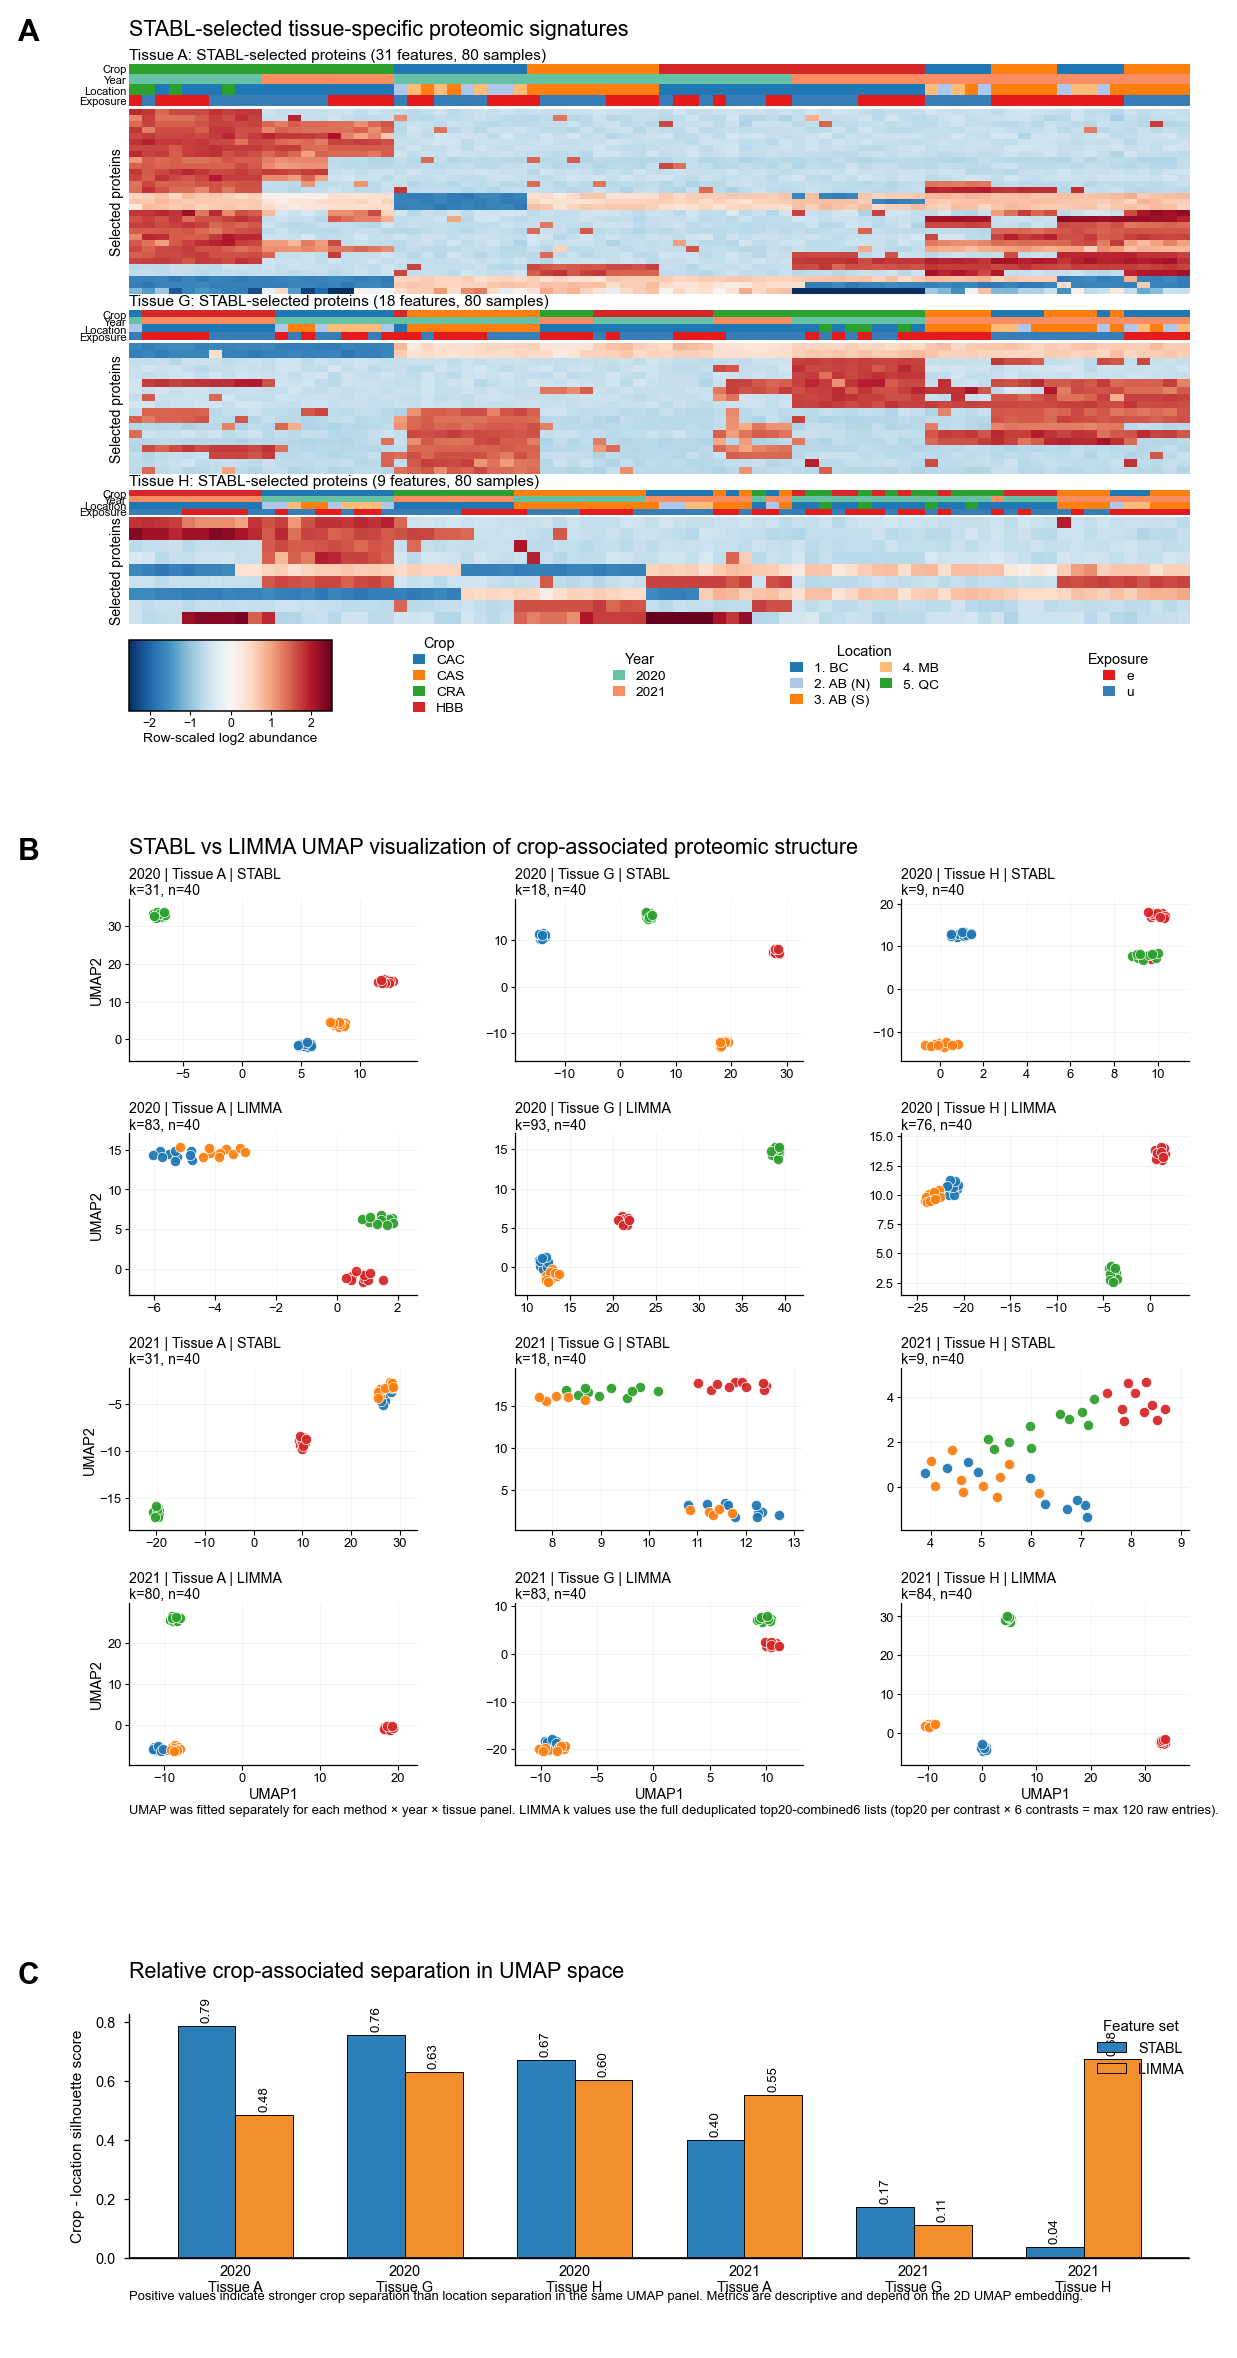

Saved refined direct-vector 170 mm combined Figure 4 panel:
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4_combined_panel_direct_vector_refined_170mm_width.png
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4_combined_panel_direct_vector_refined_170mm_width.pdf
c:\Users\junse\Documents\research\Bee_Protein_RNA_Microbes\Demographics\Figure4a\results\figure4_stabl_vs_limma_top20combined6_max120_panel170mm\Figure4_combined_panel_direct_vector_refined_170mm_width.svg
Panel width: 170 mm = 6.693 inches
Panel height: 13.80 inches
Note: this panel is redrawn from data, not assembled from PNG screenshots.


In [26]:
# ============================================================
# 12. Combined publication panel drawn directly as vector graphics
#     Refined 170 mm journal-width version with tighter spacing
# ============================================================
# This version redraws Figure 4A/4B/4C directly from data.
# It does NOT stitch saved PNG figures.
#
# Design goals:
# - Fixed 170 mm width for manuscript use
# - A/B/C labels only are bold
# - Reduced vertical gaps between panels
# - Avoid overlap between Panel C caption and x-axis labels
# - Keep PDF/SVG vector-friendly

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.patches import Patch
import matplotlib as mpl

# -------------------------
# Publication export setup
# -------------------------
mpl.rcParams["figure.dpi"] = 180
mpl.rcParams["savefig.dpi"] = 900
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "Arial"


def mm_to_inch(mm):
    return mm / 25.4


PANEL_WIDTH_MM = 170
PANEL_WIDTH_IN = mm_to_inch(PANEL_WIDTH_MM)

# Slightly shorter than before to reduce white space,
# but still tall enough to prevent overlap.
PANEL_HEIGHT_IN = 13.8

# In the combined panel, row labels make Panel A visually crowded.
# Keep False for the final manuscript panel.
SHOW_PROTEIN_ROW_LABELS = False


def legend_axis(ax, title, palette, ncol=1, fontsize=5.5, title_fontsize=5.8):
    ax.set_axis_off()

    handles = [
        Patch(facecolor=color, edgecolor="none", label=str(label))
        for label, color in palette.items()
    ]

    ax.legend(
        handles=handles,
        title=title,
        loc="center left",
        frameon=False,
        ncol=ncol,
        fontsize=fontsize,
        title_fontsize=title_fontsize,
        handlelength=0.90,
        handleheight=0.70,
        columnspacing=0.75,
        labelspacing=0.25,
        borderaxespad=0.0,
    )


def draw_compact_heatmap(ax, Xz, show_row_labels=False):
    im = ax.imshow(
        Xz.values,
        aspect="auto",
        interpolation="nearest",
        cmap="RdBu_r",
        vmin=-2.5,
        vmax=2.5,
        rasterized=True,
    )

    ax.set_xticks([])

    if show_row_labels:
        n_features = Xz.shape[0]

        if n_features <= 20:
            tick_positions = np.arange(n_features)
        elif n_features <= 40:
            tick_positions = np.arange(0, n_features, 3)
        else:
            tick_positions = np.arange(0, n_features, 5)

        ax.set_yticks(tick_positions)
        ax.set_yticklabels(
            [Xz.index[pos] for pos in tick_positions],
            fontsize=4.3,
            ha="right",
        )
    else:
        ax.set_yticks([])
        ax.set_ylabel("Selected proteins", fontsize=5.6, labelpad=2.0)

    ax.tick_params(axis="both", length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    return im


def plot_umap_points_compact(ax, d, color_col, palette):
    for _, row in d.iterrows():
        label = str(row[color_col])

        ax.scatter(
            row["UMAP1"],
            row["UMAP2"],
            s=17,
            alpha=0.94,
            color=palette.get(label, "lightgray"),
            edgecolor="white",
            linewidth=0.30,
        )


def clean_umap_axis_compact(ax, show_xlabel=False, show_ylabel=False):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.50)
    ax.spines["bottom"].set_linewidth(0.50)

    ax.tick_params(axis="both", labelsize=5.2, length=1.8, width=0.45, pad=1.2)
    ax.grid(True, linewidth=0.25, alpha=0.22)

    ax.set_xlabel("UMAP1" if show_xlabel else "", fontsize=5.8, labelpad=1.2)
    ax.set_ylabel("UMAP2" if show_ylabel else "", fontsize=5.8, labelpad=1.2)


def draw_panel_A(fig, subplot_spec):
    """Panel A: STABL-selected protein heatmaps."""
    gsA = GridSpecFromSubplotSpec(
        nrows=5,
        ncols=1,
        subplot_spec=subplot_spec,
        height_ratios=[0.20, 1.55, 1.10, 0.90, 0.48],
        hspace=0.13,
    )

    # Title row
    ax_title = fig.add_subplot(gsA[0, 0])
    ax_title.set_axis_off()

    ax_title.text(
        -0.105,
        0.95,
        "A",
        transform=ax_title.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        fontweight="bold",
    )

    ax_title.text(
        0.0,
        0.95,
        "STABL-selected tissue-specific proteomic signatures",
        transform=ax_title.transAxes,
        ha="left",
        va="top",
        fontsize=8.6,
    )

    last_im = None

    for i, tissue in enumerate(TISSUES):
        Xz = stabl_heatmap_data[tissue]["Xz"]
        sample_meta = stabl_heatmap_data[tissue]["sample_meta"]

        inner = GridSpecFromSubplotSpec(
            nrows=2,
            ncols=1,
            subplot_spec=gsA[i + 1, 0],
            height_ratios=[0.23, 1.0],
            hspace=0.030,
        )

        ax_annot = fig.add_subplot(inner[0, 0])
        ax_heat = fig.add_subplot(inner[1, 0])

        ax_annot.set_title(
            f"Tissue {tissue}: STABL-selected proteins "
            f"({Xz.shape[0]} features, {Xz.shape[1]} samples)",
            loc="left",
            fontsize=6.2,
            pad=1.8,
        )

        draw_annotation_bars(ax_annot, sample_meta)
        ax_annot.tick_params(axis="y", labelsize=4.5, pad=1.0)

        last_im = draw_compact_heatmap(
            ax_heat,
            Xz,
            show_row_labels=SHOW_PROTEIN_ROW_LABELS,
        )

    # Colorbar + legends
    gsA_leg = GridSpecFromSubplotSpec(
        nrows=1,
        ncols=5,
        subplot_spec=gsA[4, 0],
        width_ratios=[1.55, 0.95, 0.78, 1.70, 0.82],
        wspace=0.50,
    )

    cax = fig.add_subplot(gsA_leg[0, 0])
    cbar = fig.colorbar(last_im, cax=cax, orientation="horizontal")
    cbar.set_label("Row-scaled log2 abundance", fontsize=5.5, labelpad=1.0)
    cbar.ax.tick_params(labelsize=4.9, length=1.6, width=0.45, pad=1.0)

    legend_axis(fig.add_subplot(gsA_leg[0, 1]), "Crop", crop_palette, ncol=1)
    legend_axis(fig.add_subplot(gsA_leg[0, 2]), "Year", year_palette, ncol=1)
    legend_axis(fig.add_subplot(gsA_leg[0, 3]), "Location", location_palette, ncol=2)
    legend_axis(fig.add_subplot(gsA_leg[0, 4]), "Exposure", exposure_palette, ncol=1)


def draw_panel_B(fig, subplot_spec):
    """Panel B: UMAP comparison."""
    outer = GridSpecFromSubplotSpec(
        nrows=3,
        ncols=1,
        subplot_spec=subplot_spec,
        height_ratios=[0.25, 5.55, 0.30],
        hspace=0.075,
    )

    # Title row
    ax_title = fig.add_subplot(outer[0, 0])
    ax_title.set_axis_off()

    ax_title.text(
        -0.105,
        0.95,
        "B",
        transform=ax_title.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        fontweight="bold",
    )

    ax_title.text(
        0.0,
        0.95,
        "STABL vs LIMMA UMAP visualization of crop-associated proteomic structure",
        transform=ax_title.transAxes,
        ha="left",
        va="top",
        fontsize=8.6,
    )

    row_specs = [
        (2020, "STABL"),
        (2020, "LIMMA"),
        (2021, "STABL"),
        (2021, "LIMMA"),
    ]

    gsB = GridSpecFromSubplotSpec(
        nrows=len(row_specs),
        ncols=len(TISSUES),
        subplot_spec=outer[1, 0],
        wspace=0.34,
        hspace=0.45,
    )

    for r, (year, method) in enumerate(row_specs):
        for c, tissue in enumerate(TISSUES):
            ax = fig.add_subplot(gsB[r, c])

            d = umap_all[
                (umap_all["method"].astype(str) == method)
                & (umap_all["source_year"].astype(int) == int(year))
                & (umap_all["tissue"].astype(str) == tissue)
            ].copy()

            if d.empty:
                ax.text(
                    0.5,
                    0.5,
                    f"No samples\n{year}, {method}, Tissue {tissue}",
                    ha="center",
                    va="center",
                    fontsize=6,
                )
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            plot_umap_points_compact(ax, d, color_col="crop", palette=crop_palette)

            xlim, ylim = get_panel_axis_limits(d)
            ax.set_xlim(*xlim)
            ax.set_ylim(*ylim)

            clean_umap_axis_compact(
                ax,
                show_xlabel=(r == len(row_specs) - 1),
                show_ylabel=(c == 0),
            )

            k = int(d["n_features"].iloc[0])
            n = int(d["n_samples"].iloc[0])

            ax.set_title(
                f"{year} | Tissue {tissue} | {method}\n"
                f"k={k}, n={n}",
                loc="left",
                fontsize=5.7,
                pad=1.8,
            )

    # Caption row
    ax_caption = fig.add_subplot(outer[2, 0])
    ax_caption.set_axis_off()

    ax_caption.text(
        0.0,
        0.55,
        "UMAP was fitted separately for each method × year × tissue panel. "
        "LIMMA k values use the full deduplicated top20-combined6 lists "
        "(top20 per contrast × 6 contrasts = max 120 raw entries).",
        transform=ax_caption.transAxes,
        ha="left",
        va="center",
        fontsize=5.2,
    )


def draw_panel_C(fig, subplot_spec):
    """Panel C: silhouette delta bar plot."""
    outer = GridSpecFromSubplotSpec(
        nrows=3,
        ncols=1,
        subplot_spec=subplot_spec,
        height_ratios=[0.25, 1.75, 0.45],
        hspace=0.17,
    )

    ax_title = fig.add_subplot(outer[0, 0])
    ax_title.set_axis_off()

    ax_title.text(
        -0.105,
        0.95,
        "C",
        transform=ax_title.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        fontweight="bold",
    )

    ax_title.text(
        0.0,
        0.95,
        "Relative crop-associated separation in UMAP space",
        transform=ax_title.transAxes,
        ha="left",
        va="top",
        fontsize=8.6,
    )

    ax = fig.add_subplot(outer[1, 0])

    df = separation_summary.copy()
    df["method"] = df["method"].astype(str)
    df["year"] = df["year"].astype(int)
    df["tissue"] = df["tissue"].astype(str)

    row_keys = []
    x_labels = []

    for year in YEARS:
        for tissue in TISSUES:
            row_keys.append((year, tissue))
            x_labels.append(f"{year}\nTissue {tissue}")

    x = np.arange(len(row_keys))
    width = 0.34
    method_palette = {"STABL": "#2C7FB8", "LIMMA": "#F28E2B"}

    for j, method in enumerate(METHODS):
        vals = []

        for year, tissue in row_keys:
            row = df[
                (df["method"] == method)
                & (df["year"] == int(year))
                & (df["tissue"] == tissue)
            ]

            if row.empty:
                vals.append(np.nan)
            else:
                vals.append(float(row["silhouette_delta_crop_minus_location"].iloc[0]))

        offset = (j - 0.5) * width

        ax.bar(
            x + offset,
            vals,
            width,
            label=method,
            color=method_palette.get(method, None),
            edgecolor="black",
            linewidth=0.38,
        )

        for i, value in enumerate(vals):
            if pd.isna(value):
                continue

            y_offset = 0.012 if value >= 0 else -0.014

            ax.text(
                x[i] + offset,
                value + y_offset,
                f"{value:.2f}",
                ha="center",
                va="bottom" if value >= 0 else "top",
                fontsize=5.3,
                rotation=90,
            )

    ax.axhline(0, color="black", linewidth=0.65)

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=5.8)
    ax.set_ylabel("Crop - location silhouette score", fontsize=6.2)

    ax.tick_params(axis="y", labelsize=5.8, length=2.0, width=0.50)
    ax.tick_params(axis="x", length=0, pad=2.5)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.55)
    ax.spines["bottom"].set_linewidth(0.55)

    ax.legend(
        frameon=False,
        fontsize=5.8,
        title="Feature set",
        title_fontsize=6.0,
        loc="upper right",
        bbox_to_anchor=(1.00, 1.00),
        borderaxespad=0.0,
    )

    ax_caption = fig.add_subplot(outer[2, 0])
    ax_caption.set_axis_off()

    ax_caption.text(
        0.0,
        0.70,
        "Positive values indicate stronger crop separation than location separation in the same UMAP panel. "
        "Metrics are descriptive and depend on the 2D UMAP embedding.",
        transform=ax_caption.transAxes,
        fontsize=5.2,
        ha="left",
        va="center",
    )


def plot_combined_figure4_direct_vector_refined():
    """Create a refined 170 mm wide Figure 4 panel without raster-stitching existing figures."""
    fig = plt.figure(
        figsize=(PANEL_WIDTH_IN, PANEL_HEIGHT_IN),
        constrained_layout=False,
        facecolor="white",
    )

    main = GridSpec(
        nrows=3,
        ncols=1,
        figure=fig,
        height_ratios=[4.20, 6.05, 2.30],
        hspace=0.18,
        left=0.105,
        right=0.985,
        top=0.985,
        bottom=0.050,
    )

    draw_panel_A(fig, main[0, 0])
    draw_panel_B(fig, main[1, 0])
    draw_panel_C(fig, main[2, 0])

    return fig


fig4_panel_direct_refined = plot_combined_figure4_direct_vector_refined()

fig4_panel_direct_refined_png = RESULTS_DIR / "Figure4_combined_panel_direct_vector_refined_170mm_width.png"
fig4_panel_direct_refined_pdf = RESULTS_DIR / "Figure4_combined_panel_direct_vector_refined_170mm_width.pdf"
fig4_panel_direct_refined_svg = RESULTS_DIR / "Figure4_combined_panel_direct_vector_refined_170mm_width.svg"

# Do not use bbox_inches='tight' because it changes the final physical width.
fig4_panel_direct_refined.savefig(
    fig4_panel_direct_refined_png,
    dpi=900,
    facecolor="white",
)

fig4_panel_direct_refined.savefig(
    fig4_panel_direct_refined_pdf,
    facecolor="white",
)

fig4_panel_direct_refined.savefig(
    fig4_panel_direct_refined_svg,
    facecolor="white",
)

plt.show()

print("Saved refined direct-vector 170 mm combined Figure 4 panel:")
print(fig4_panel_direct_refined_png)
print(fig4_panel_direct_refined_pdf)
print(fig4_panel_direct_refined_svg)
print(f"Panel width: {PANEL_WIDTH_MM} mm = {PANEL_WIDTH_IN:.3f} inches")
print(f"Panel height: {PANEL_HEIGHT_IN:.2f} inches")
print("Note: this panel is redrawn from data, not assembled from PNG screenshots.")

In [27]:
# ============================================================
# 13. Final output summary and caption draft
# ============================================================

output_files = [
    fig4a_png, fig4a_pdf, fig4a_svg,
    fig4b_png, fig4b_pdf, fig4b_svg,
    fig4b_location_png, fig4b_location_pdf, fig4b_location_svg,
    fig4c_bar_png, fig4c_bar_pdf, fig4c_bar_svg,
    fig4c_heatmap_png, fig4c_heatmap_pdf, fig4c_heatmap_svg,
    fig4_panel_direct_png, fig4_panel_direct_pdf, fig4_panel_direct_svg,
    umap_coord_path,
    umap_metric_path,
    summary_csv_path,
    feature_source_summary_path,
    RESULTS_DIR / "Figure4A_STABL_heatmap_feature_manifest.csv",
    RESULTS_DIR / "Figure4A_STABL_heatmap_summary.csv",
    RESULTS_DIR / "Figure4_method_year_tissue_umap_input_summary.csv",
]

print("=" * 90)
print("Figure 4 STABL vs LIMMA top20-combined6 max120 generation complete.")
print("=" * 90)

print("\nSaved output files:")
for f in output_files:
    print(" -", f)

print("\nSuggested figure layout:")
print("Figure 4A: STABL-selected protein heatmap")
print("Figure 4B: STABL vs LIMMA UMAP comparison colored by crop")
print("Figure 4C: STABL vs LIMMA quantitative separation summary")
print("Combined panel: Figure 4A/B/C redrawn directly at 170 mm width")

print("\nRecommended interpretation note:")
print(
    "UMAP should be interpreted as descriptive visualization only. "
    "For LIMMA, k values are not forced to 20; they reflect the usable deduplicated "
    "features from each year-specific top20-combined6 no-Nosema file, where the expected upper bound is top20 × 6 = 120 raw entries before deduplication."
)


NameError: name 'fig4_panel_direct_png' is not defined

## Draft caption

**Figure 4. STABL-selected proteomic signatures and comparison with LIMMA-derived crop-associated features.**  
**(A)** Heatmap of STABL-selected tissue-specific proteomic features. Rows represent selected protein features and columns represent samples within each tissue. Heatmap values show row-scaled log2 protein abundance using 2020 samples as the scaling reference. Column annotations indicate crop, year, geographic region, and exposure status.  
**(B)** UMAP visualization comparing STABL-selected and LIMMA-derived features across year × tissue panels. Each point represents one sample and is colored by crop. UMAP was fitted separately within each method × year × tissue panel, so coordinates are descriptive and not directly comparable across panels. LIMMA feature counts reflect the full deduplicated year-specific `top20_combined6` no-Nosema files, interpreted as top 20 features per pairwise crop contrast across six crop contrasts, rather than a forced k = 20 subset.  
**(C)** Quantitative comparison of crop-associated separation relative to location-associated separation in UMAP space. Positive values indicate stronger crop separation than location separation, whereas values near zero indicate weak or comparable structure. These metrics are descriptive and should be interpreted alongside the supervised classification results.


**Combined panel output.** The final combined Figure 4 panel is saved at **170 mm width** as PNG, PDF, and SVG. This panel is assembled from the generated Figure 4A, Figure 4B, and Figure 4C files so it can be used directly for manuscript layout checking.
